In [1]:
#from google.colab import drive; import os; drive.mount('/content/drive'); os.makedirs('/content/drive/MyDrive/space_robotics', exist_ok=True)


In [60]:
'''
import sys
!{sys.executable} -m pip install pulp

'''

'\nimport sys\n!{sys.executable} -m pip install pulp\n\n'

In [1]:
from tqdm.auto import tqdm
import time
import sys
import numpy as np
import pandas as pd

/home/raj/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import time
import sys
import numpy as np

app = None
try:
    import omni.kit.app
    app = omni.kit.app.get_app()
except Exception:
    app = None

# Constants
G = 6.67430e-11
M_earth = 5.972e24
R_earth = 6.371e6
h_sat = 500e3  # satellite height in meters

r_sat = R_earth + h_sat
T_sat = 2 * np.pi * np.sqrt(r_sat**3 / (G * M_earth))
omega_sat = 2 * np.pi / T_sat  # satellite angular velocity in rad/s

# Basis vectors
i_cap = np.array([1.0, 0.0, 0.0])
j_cap = np.array([0.0, 1.0, 0.0])
k_cap = np.array([0.0, 0.0, 1.0])


# --- helper functions ---
def rotate_vector_around_axis_by_angle(vector, axis, angle_rad):
    vector = np.array(vector, float)
    axis = np.array(axis, float)
    axis /= np.linalg.norm(axis)
    t = angle_rad
    rotated = vector * np.cos(t) + np.cross(axis, vector) * np.sin(t) + axis * np.dot(axis, vector) * (1 - np.cos(t))
    rotated /= np.linalg.norm(rotated)
    return rotated


def create_circular_trajectory_parameters_for_rectannas(lat_rad=0.0, long_rad=0.0, radius_earth=R_earth):
    """
    Rectenna on Earth. All angles in radians.
    """
    center = radius_earth * np.sin(lat_rad) * k_cap
    radius = radius_earth * np.cos(lat_rad)
    u = i_cap
    v = j_cap
    omega = 2 * np.pi / 86400  # Earth rotation rad/s
    return [center, radius, u, v, omega]


def create_circular_trajectory_parameters_for_satelites(theta_inclination_rad=0.0, raan_rad=0.0, radius_orbit=r_sat):
    """
    Satellite trajectory. All angles in radians.
    """
    center = np.zeros(3)
    u = i_cap * np.cos(raan_rad) + j_cap * np.sin(raan_rad)
    f = np.cross(k_cap, u)
    v = rotate_vector_around_axis_by_angle(f, u, theta_inclination_rad)
    omega = omega_sat
    radius = radius_orbit
    return [center, radius, u, v, omega]


def find_position_in_space_with_3d_circular_trajectory(center, radius, u, v, omega, time=0, verbose=False):
    angular_position = omega * time  # radians
    if verbose:
        print("Angular position at time =", time, "is", angular_position)
    return center + radius * (u * np.cos(angular_position) + v * np.sin(angular_position))


def rays_are_similar(u, v, theta_threshold_rad, tol=1e-12):
    """
    Compare two vectors. All angles in radians.
    """
    u = np.array(u, float)
    v = np.array(v, float)
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu <= tol or nv <= tol:
        raise ValueError("u or v is zero — cannot define ray direction.")
    dot = np.dot(u, v)
    cos_theta = np.clip(dot / (nu * nv), -1, 1)
    theta = np.arccos(cos_theta)
    return (dot > 0) and (theta < theta_threshold_rad), theta



In [3]:
file_path = '/media/raj/New_Volume_F/SEM3/space_robotics/project_2/rectanna_placement.csv'

# Load CSV into a DataFrame
data_rectanna_placement_degrees = pd.read_csv(file_path)

# Optional: view first few rows
data_rectanna_placement_radians=np.radians(data_rectanna_placement_degrees)
data_rectanna_placement_radians

,x,y
0,0.794412,0.661670
1,0.063660,-1.259791
2,0.433655,1.365990
3,1.068314,-2.104112
4,1.113790,2.161475
5,0.457652,0.158797
6,-0.144542,2.436178
7,1.280683,-0.848478
8,0.158490,0.276183
9,1.123878,1.545994


In [4]:

# --- simulation loop ---
cnt = 0
start = time.time()
total_seconds = 86400 * 6  # iterations
theta_threshold_rad = 10 * np.pi / 180  # convert 10 degrees to radians
lat=20
lng=20
# Make sure lat/long are in radians
lat_rad = lat * np.pi / 180
long_rad = lng * np.pi / 180
params_sats = create_circular_trajectory_parameters_for_satelites(theta_inclination_rad=np.deg2rad(53), raan_rad=0)


for i in tqdm(range(total_seconds)):
    params_rectannas = create_circular_trajectory_parameters_for_rectannas(lat_rad=lat_rad, long_rad=long_rad)

    pos_rectannas = find_position_in_space_with_3d_circular_trajectory(
        center=params_rectannas[0],
        radius=params_rectannas[1],
        u=params_rectannas[2],
        v=params_rectannas[3],
        omega=params_rectannas[4],
        time=i
    )

    pos_sats = find_position_in_space_with_3d_circular_trajectory(
        center=params_sats[0],
        radius=params_sats[1],
        u=params_sats[2],
        v=params_sats[3],
        omega=params_sats[4],
        time=i
    )

    bool_value, theta_value = rays_are_similar(
        pos_rectannas,
        pos_sats,
        theta_threshold_rad
    )

    if bool_value:
        cnt += 1

# --- total time elapsed ---
end = time.time()
elapsed = end - start

def format_hms(s):
    s = int(s)
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}h {m:02d}m {sec:02d}s"

print(f"Total count: {cnt}, ratio: {cnt/total_seconds:.6f}")
print(f"Total time elapsed: {elapsed:.2f} seconds ({format_hms(elapsed)})")


100%|███████████████████████████████████████████████████████████████████████████████████| 518400/518400 [00:10<00:00, 50142.72it/s]

Total count: 3493, ratio: 0.006738
Total time elapsed: 10.35 seconds (0h 00m 10s)


In [5]:
import time
import numpy as np

from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Tuple

# ---------- Physical constants ----------
G = 6.67430e-11
M_earth = 5.972e24
R_earth = 6.371e6

# ---------- Utilities & optimized helpers ----------
def format_hms(s: float) -> str:
    s = int(s)
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}h {m:02d}m {sec:02d}s"

def rotate_vector_around_axis_by_angle(vector: np.ndarray, axis: np.ndarray, angle_rad: float) -> np.ndarray:
    """
    Rodrigues rotation formula. Returns a unit-normalized rotated vector.
    """
    v = np.array(vector, dtype=float)
    a = np.array(axis, dtype=float)
    a /= np.linalg.norm(a)
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    rotated = v * c + np.cross(a, v) * s + a * (np.dot(a, v)) * (1 - c)
    # normalize (avoid tiny numerical drift)
    return rotated / np.linalg.norm(rotated)

# ---------- Trajectory parameter creators (optimized) ----------
_k_cap = np.array([0.0, 0.0, 1.0])
_i_cap = np.array([1.0, 0.0, 0.0])
_j_cap = np.array([0.0, 1.0, 0.0])

def create_circular_trajectory_parameters_for_satelites(theta_inclination_rad: float = 0.0,
                                                        raan_rad: float = 0.0,
                                                        radius_orbit: float = None) -> Tuple[np.ndarray, float, np.ndarray, np.ndarray, float]:
    """
    Build satellite trajectory parameters (center, radius, u, v, omega).
    Returns:
      center (3,), radius (scalar), u (3,), v (3,), omega (rad/s)
    """
    if radius_orbit is None:
        raise ValueError("radius_orbit must be provided (e.g., R_earth + h_sat)")
    # orbital plane basis: u is the node direction in equatorial plane rotated by RAAN
    u = _i_cap * np.cos(raan_rad) + _j_cap * np.sin(raan_rad)
    # f is cross(k, u) -- a vector in equatorial plane perpendicular to u
    f = np.cross(_k_cap, u)
    # v is f rotated around u by inclination
    v = rotate_vector_around_axis_by_angle(f, u, theta_inclination_rad)
    # satellite angular velocity assuming circular orbit (Kepler)
    omega = 2 * np.pi * np.sqrt(radius_orbit**-3 * (G * M_earth))
    center = np.zeros(3, dtype=float)
    return center, radius_orbit, u, v, omega

def create_circular_trajectory_parameters_for_rectannas(lat_rad: float = 0.0,
                                                        long_rad: float = 0.0,
                                                        radius_earth: float = R_earth,
                                                        earth_rotation_rate: float = 2 * np.pi / 86400.0) -> Tuple[np.ndarray, float, np.ndarray, np.ndarray, float, float]:
    """
    Returns parameters to generate the rectenna position as:
      pos(t) = center + radius * (u*cos(omega*t + phase) + v*sin(omega*t + phase))
    where `phase` encodes the longitude offset.
    Returns:
      center (3,), radius (scalar), u (3,), v (3,), omega (rad/s), phase (rad)
    """
    # Center of the circular parallel-of-latitude (z offset)
    z = radius_earth * np.sin(lat_rad)
    center = np.array([0.0, 0.0, z], dtype=float)
    # Radius of the parallel circle (in XY plane)
    r_parallel = radius_earth * np.cos(lat_rad)
    # Choose local basis u,v in the equatorial XY plane rotated by longitude
    u = np.array([np.cos(long_rad), np.sin(long_rad), 0.0], dtype=float)  # point at longitude on equator
    v = np.cross(_k_cap, u)  # points "90 deg ahead" in equatorial plane
    # Earth rotation rate (radians per second)
    omega = earth_rotation_rate
    # phase: we've baked longitude into u/v, so keep phase = 0 (but we still return it for API completeness)
    phase = 0.0
    return center, r_parallel, u, v, omega, phase

def find_position_in_space_with_3d_circular_trajectory(center: np.ndarray,
                                                       radius: float,
                                                       u: np.ndarray,
                                                       v: np.ndarray,
                                                       omega: float,
                                                       time: np.ndarray,
                                                       phase: float = 0.0) -> np.ndarray:
    """
    Vectorized: time can be scalar or 1D numpy array.
    Returns an array of shape (T,3) for T times, or (3,) for a scalar time.
    """
    t = np.asarray(time)
    ang = omega * t + phase
    c = np.cos(ang)
    s = np.sin(ang)
    # If times are scalar -> return 3-vector
    if c.ndim == 0:
        return center + radius * (u * c + v * s)
    # else return (T,3)
    # shape (T,1) x (3,) -> (T,3)
    return center + radius * (c[:, None] * u[None, :] + s[:, None] * v[None, :])

# ---------- Fast ray similarity (no arccos) ----------
def rays_are_similar_fast(arr_u: np.ndarray, arr_v: np.ndarray, cos_theta_threshold: float) -> np.ndarray:
    """
    Compare two sets of vectors in a vectorized fashion.
    arr_u: shape (...,3)
    arr_v: shape (...,3)
    cos_theta_threshold: scalar = cos(theta_threshold_rad)
    Returns boolean mask where each element is True if:
       dot(u, v) > 0 and (dot/(|u||v|) > cos_theta_threshold)
    """
    # compute dot and norms along last axis
    dot = np.sum(arr_u * arr_v, axis=-1)
    nu = np.linalg.norm(arr_u, axis=-1)
    nv = np.linalg.norm(arr_v, axis=-1)
    denom = nu * nv
    # avoid division by zero
    valid = denom > 0
    cos_vals = np.empty_like(dot, dtype=float)
    cos_vals[~valid] = -1.0  # impossible
    cos_vals[valid] = dot[valid] / denom[valid]
    # compare using cosine threshold and positive dot
    return (dot > 0) & (cos_vals > cos_theta_threshold)

# ---------- Main optimized function (vectorized + threaded modes) ----------
def calculate_ratio_activation_optimized(theta_inclination_deg: float,
                                         raan_deg: float,
                                         total_time_seconds: int,
                                         lat_long_array: np.ndarray,
                                         theta_threshold_deg: float = 10.0,
                                         mode: str = "vectorized",
                                         chunk_size: int = 3600,
                                         max_workers: int = None,
                                         orbit_height_m: float = 500e3) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Optimized & multithreaded/ vectorized implementation of the simulation.
    Args:
      - theta_inclination_deg, raan_deg: satellite orbit parameters (degrees)
      - total_time_seconds: number of seconds to simulate (T)
      - lat_long_array: shape (N,2) lat, long in degrees
      - theta_threshold_deg: angular threshold in degrees
      - mode: "vectorized" (default) or "threaded"
      - chunk_size: when vectorized and T is huge, break times into chunks of this size to limit memory
      - max_workers: used by ThreadPoolExecutor when mode == "threaded". Default -> os default.
      - orbit_height_m: satellite altitude above Earth's radius
    Returns:
      counts (N,), ratios (N,), elapsed_time_sec
    """
    assert mode in ("vectorized", "threaded"), "mode must be 'vectorized' or 'threaded'"
    lat_long_array = np.asarray(lat_long_array, dtype=float)
    N = lat_long_array.shape[0]
    counts = np.zeros(N, dtype=np.int64)

    # Precompute angles
    theta_inclination_rad = np.deg2rad(theta_inclination_deg)
    raan_rad = np.deg2rad(raan_deg)
    theta_threshold_rad = np.deg2rad(theta_threshold_deg)
    cos_theta_threshold = np.cos(theta_threshold_rad)

    # Satellite orbit radius and params
    radius_orbit = R_earth + orbit_height_m
    params_sats = create_circular_trajectory_parameters_for_satelites(
        theta_inclination_rad=theta_inclination_rad,
        raan_rad=raan_rad,
        radius_orbit=radius_orbit
    )
    sat_center, sat_radius, sat_u, sat_v, sat_omega = params_sats

    # Precompute all satellite positions for all times in chunks (vectorized)
    start_time = time.time()

    times = np.arange(total_time_seconds, dtype=float)

    # --- Vectorized mode (fastest when memory fits) ---
    if mode == "vectorized":
        # To handle very large T, iterate in chunks of chunk_size
        for t0 in tqdm(range(0, total_time_seconds, chunk_size), desc="vectorized-chunks"):
            t1 = min(total_time_seconds, t0 + chunk_size)
            t_chunk = times[t0:t1]  # shape (K,)
            # satellite positions: (K,3)
            pos_sats_chunk = find_position_in_space_with_3d_circular_trajectory(
                sat_center, sat_radius, sat_u, sat_v, sat_omega, time=t_chunk
            )  # (K,3)
            # precompute norms of satellite per time
            # For each rectenna we will broadcast pos_rect (K,3) against pos_sats_chunk (K,3)
            for idx in range(N):
                lat_deg, long_deg = lat_long_array[idx]
                lat_rad = np.deg2rad(lat_deg)
                long_rad = np.deg2rad(long_deg)
                # rectenna params
                center_r, r_par, u_r, v_r, omega_r, phase_r = create_circular_trajectory_parameters_for_rectannas(
                    lat_rad=lat_rad, long_rad=long_rad
                )
                # rectenna positions over chunk times
                pos_rect_chunk = find_position_in_space_with_3d_circular_trajectory(
                    center_r, r_par, u_r, v_r, omega_r, time=t_chunk, phase=phase_r
                )  # (K,3)
                # fast vectorized ray similarity
                mask = rays_are_similar_fast(pos_rect_chunk, pos_sats_chunk, cos_theta_threshold)
                counts[idx] += int(np.count_nonzero(mask))

    # --- Threaded mode: each rectenna gets computed in a worker, with time-chunking inside worker ---
    else:
        def worker_rectenna(idx_local: int) -> Tuple[int, int]:
            lat_deg, long_deg = lat_long_array[idx_local]
            lat_rad = np.deg2rad(lat_deg)
            long_rad = np.deg2rad(long_deg)
            center_r, r_par, u_r, v_r, omega_r, phase_r = create_circular_trajectory_parameters_for_rectannas(
                lat_rad=lat_rad, long_rad=long_rad
            )
            local_count = 0
            # iterate over time chunks to reduce memory
            for t0 in range(0, total_time_seconds, chunk_size):
                t1 = min(total_time_seconds, t0 + chunk_size)
                t_chunk = times[t0:t1]
                pos_rect_chunk = find_position_in_space_with_3d_circular_trajectory(
                    center_r, r_par, u_r, v_r, omega_r, time=t_chunk, phase=phase_r
                )  # (K,3)
                pos_sats_chunk = find_position_in_space_with_3d_circular_trajectory(
                    sat_center, sat_radius, sat_u, sat_v, sat_omega, time=t_chunk
                )  # (K,3)
                mask = rays_are_similar_fast(pos_rect_chunk, pos_sats_chunk, cos_theta_threshold)
                local_count += int(np.count_nonzero(mask))
            return idx_local, local_count

        # submit tasks
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(worker_rectenna, idx) for idx in range(N)]
            for fut in tqdm(as_completed(futures), total=N, desc="threaded-rectennas"):
                idx_done, cnt_done = fut.result()
                counts[idx_done] = cnt_done

    elapsed = time.time() - start_time
    ratios = counts.astype(float) / float(total_time_seconds)
    return counts, ratios, elapsed

# ---------- Example usage ----------
if __name__ == "__main__":
    # small quick test
    lat_long_array = np.array([
        [20.0, 20.0],
        [34.0, -118.0],
        [51.5, -0.1],
    ])
    total_time_seconds = 24 * 3600  # 1 day for quick test
    counts, ratios, elapsed = calculate_ratio_activation_optimized(
        theta_inclination_deg=53.0,
        raan_deg=0.0,
        total_time_seconds=total_time_seconds,
        lat_long_array=lat_long_array,
        theta_threshold_deg=10.0,
        mode="vectorized",   # try "threaded" if memory is tight
        chunk_size=3600      # 1-hour chunks
    )
    print("counts:", counts)
    print("ratios:", ratios)
    print(f"elapsed: {elapsed:.2f} s ({format_hms(elapsed)})")
import time
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Tuple

# ---------- Physical constants ----------
G = 6.67430e-11
M_earth = 5.972e24
R_earth = 6.371e6

# ---------- Utilities & optimized helpers ----------
def format_hms(s: float) -> str:
    s = int(s)
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}h {m:02d}m {sec:02d}s"

def rotate_vector_around_axis_by_angle(vector: np.ndarray, axis: np.ndarray, angle_rad: float) -> np.ndarray:
    """
    Rodrigues rotation formula. Returns a unit-normalized rotated vector.
    """
    v = np.array(vector, dtype=float)
    a = np.array(axis, dtype=float)
    a /= np.linalg.norm(a)
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    rotated = v * c + np.cross(a, v) * s + a * (np.dot(a, v)) * (1 - c)
    # normalize (avoid tiny numerical drift)
    return rotated / np.linalg.norm(rotated)

# ---------- Trajectory parameter creators (optimized) ----------
_k_cap = np.array([0.0, 0.0, 1.0])
_i_cap = np.array([1.0, 0.0, 0.0])
_j_cap = np.array([0.0, 1.0, 0.0])

def create_circular_trajectory_parameters_for_satelites(theta_inclination_rad: float = 0.0,
                                                        raan_rad: float = 0.0,
                                                        radius_orbit: float = None) -> Tuple[np.ndarray, float, np.ndarray, np.ndarray, float]:
    """
    Build satellite trajectory parameters (center, radius, u, v, omega).
    Returns:
      center (3,), radius (scalar), u (3,), v (3,), omega (rad/s)
    """
    if radius_orbit is None:
        raise ValueError("radius_orbit must be provided (e.g., R_earth + h_sat)")
    # orbital plane basis: u is the node direction in equatorial plane rotated by RAAN
    u = _i_cap * np.cos(raan_rad) + _j_cap * np.sin(raan_rad)
    # f is cross(k, u) -- a vector in equatorial plane perpendicular to u
    f = np.cross(_k_cap, u)
    # v is f rotated around u by inclination
    v = rotate_vector_around_axis_by_angle(f, u, theta_inclination_rad)
    # satellite angular velocity assuming circular orbit (Kepler)
    omega = 2 * np.pi * np.sqrt(radius_orbit**-3 * (G * M_earth))
    center = np.zeros(3, dtype=float)
    return center, radius_orbit, u, v, omega

def create_circular_trajectory_parameters_for_rectannas(lat_rad: float = 0.0,
                                                        long_rad: float = 0.0,
                                                        radius_earth: float = R_earth,
                                                        earth_rotation_rate: float = 2 * np.pi / 86400.0) -> Tuple[np.ndarray, float, np.ndarray, np.ndarray, float, float]:
    """
    Returns parameters to generate the rectenna position as:
      pos(t) = center + radius * (u*cos(omega*t + phase) + v*sin(omega*t + phase))
    where `phase` encodes the longitude offset.
    Returns:
      center (3,), radius (scalar), u (3,), v (3,), omega (rad/s), phase (rad)
    """
    # Center of the circular parallel-of-latitude (z offset)
    z = radius_earth * np.sin(lat_rad)
    center = np.array([0.0, 0.0, z], dtype=float)
    # Radius of the parallel circle (in XY plane)
    r_parallel = radius_earth * np.cos(lat_rad)
    # Choose local basis u,v in the equatorial XY plane rotated by longitude
    u = np.array([np.cos(long_rad), np.sin(long_rad), 0.0], dtype=float)  # point at longitude on equator
    v = np.cross(_k_cap, u)  # points "90 deg ahead" in equatorial plane
    # Earth rotation rate (radians per second)
    omega = earth_rotation_rate
    # phase: we've baked longitude into u/v, so keep phase = 0 (but we still return it for API completeness)
    phase = 0.0
    return center, r_parallel, u, v, omega, phase

def find_position_in_space_with_3d_circular_trajectory(center: np.ndarray,
                                                       radius: float,
                                                       u: np.ndarray,
                                                       v: np.ndarray,
                                                       omega: float,
                                                       time: np.ndarray,
                                                       phase: float = 0.0) -> np.ndarray:
    """
    Vectorized: time can be scalar or 1D numpy array.
    Returns an array of shape (T,3) for T times, or (3,) for a scalar time.
    """
    t = np.asarray(time)
    ang = omega * t + phase
    c = np.cos(ang)
    s = np.sin(ang)
    # If times are scalar -> return 3-vector
    if c.ndim == 0:
        return center + radius * (u * c + v * s)
    # else return (T,3)
    # shape (T,1) x (3,) -> (T,3)
    return center + radius * (c[:, None] * u[None, :] + s[:, None] * v[None, :])

# ---------- Fast ray similarity (no arccos) ----------
def rays_are_similar_fast(arr_u: np.ndarray, arr_v: np.ndarray, cos_theta_threshold: float) -> np.ndarray:
    """
    Compare two sets of vectors in a vectorized fashion.
    arr_u: shape (...,3)
    arr_v: shape (...,3)
    cos_theta_threshold: scalar = cos(theta_threshold_rad)
    Returns boolean mask where each element is True if:
       dot(u, v) > 0 and (dot/(|u||v|) > cos_theta_threshold)
    """
    # compute dot and norms along last axis
    dot = np.sum(arr_u * arr_v, axis=-1)
    nu = np.linalg.norm(arr_u, axis=-1)
    nv = np.linalg.norm(arr_v, axis=-1)
    denom = nu * nv
    # avoid division by zero
    valid = denom > 0
    cos_vals = np.empty_like(dot, dtype=float)
    cos_vals[~valid] = -1.0  # impossible
    cos_vals[valid] = dot[valid] / denom[valid]
    # compare using cosine threshold and positive dot
    return (dot > 0) & (cos_vals > cos_theta_threshold)

# ---------- Main optimized function (vectorized + threaded modes) ----------
def calculate_ratio_activation_optimized(theta_inclination_deg: float,
                                         raan_deg: float,
                                         total_time_seconds: int,
                                         lat_long_array: np.ndarray,
                                         theta_threshold_deg: float = 10.0,
                                         mode: str = "vectorized",
                                         chunk_size: int = 3600,
                                         max_workers: int = None,
                                         orbit_height_m: float = 500e3) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Optimized & multithreaded/ vectorized implementation of the simulation.
    Args:
      - theta_inclination_deg, raan_deg: satellite orbit parameters (degrees)
      - total_time_seconds: number of seconds to simulate (T)
      - lat_long_array: shape (N,2) lat, long in degrees
      - theta_threshold_deg: angular threshold in degrees
      - mode: "vectorized" (default) or "threaded"
      - chunk_size: when vectorized and T is huge, break times into chunks of this size to limit memory
      - max_workers: used by ThreadPoolExecutor when mode == "threaded". Default -> os default.
      - orbit_height_m: satellite altitude above Earth's radius
    Returns:
      counts (N,), ratios (N,), elapsed_time_sec
    """
    assert mode in ("vectorized", "threaded"), "mode must be 'vectorized' or 'threaded'"
    lat_long_array = np.asarray(lat_long_array, dtype=float)
    N = lat_long_array.shape[0]
    counts = np.zeros(N, dtype=np.int64)

    # Precompute angles
    theta_inclination_rad = np.deg2rad(theta_inclination_deg)
    raan_rad = np.deg2rad(raan_deg)
    theta_threshold_rad = np.deg2rad(theta_threshold_deg)
    cos_theta_threshold = np.cos(theta_threshold_rad)

    # Satellite orbit radius and params
    radius_orbit = R_earth + orbit_height_m
    params_sats = create_circular_trajectory_parameters_for_satelites(
        theta_inclination_rad=theta_inclination_rad,
        raan_rad=raan_rad,
        radius_orbit=radius_orbit
    )
    sat_center, sat_radius, sat_u, sat_v, sat_omega = params_sats

    # Precompute all satellite positions for all times in chunks (vectorized)
    start_time = time.time()

    times = np.arange(total_time_seconds, dtype=float)

    # --- Vectorized mode (fastest when memory fits) ---
    if mode == "vectorized":
        # To handle very large T, iterate in chunks of chunk_size
        for t0 in tqdm(range(0, total_time_seconds, chunk_size), desc="vectorized-chunks"):
            t1 = min(total_time_seconds, t0 + chunk_size)
            t_chunk = times[t0:t1]  # shape (K,)
            # satellite positions: (K,3)
            pos_sats_chunk = find_position_in_space_with_3d_circular_trajectory(
                sat_center, sat_radius, sat_u, sat_v, sat_omega, time=t_chunk
            )  # (K,3)
            # precompute norms of satellite per time
            # For each rectenna we will broadcast pos_rect (K,3) against pos_sats_chunk (K,3)
            for idx in range(N):
                lat_deg, long_deg = lat_long_array[idx]
                lat_rad = np.deg2rad(lat_deg)
                long_rad = np.deg2rad(long_deg)
                # rectenna params
                center_r, r_par, u_r, v_r, omega_r, phase_r = create_circular_trajectory_parameters_for_rectannas(
                    lat_rad=lat_rad, long_rad=long_rad
                )
                # rectenna positions over chunk times
                pos_rect_chunk = find_position_in_space_with_3d_circular_trajectory(
                    center_r, r_par, u_r, v_r, omega_r, time=t_chunk, phase=phase_r
                )  # (K,3)
                # fast vectorized ray similarity
                mask = rays_are_similar_fast(pos_rect_chunk, pos_sats_chunk, cos_theta_threshold)
                counts[idx] += int(np.count_nonzero(mask))

    # --- Threaded mode: each rectenna gets computed in a worker, with time-chunking inside worker ---
    else:
        def worker_rectenna(idx_local: int) -> Tuple[int, int]:
            lat_deg, long_deg = lat_long_array[idx_local]
            lat_rad = np.deg2rad(lat_deg)
            long_rad = np.deg2rad(long_deg)
            center_r, r_par, u_r, v_r, omega_r, phase_r = create_circular_trajectory_parameters_for_rectannas(
                lat_rad=lat_rad, long_rad=long_rad
            )
            local_count = 0
            # iterate over time chunks to reduce memory
            for t0 in range(0, total_time_seconds, chunk_size):
                t1 = min(total_time_seconds, t0 + chunk_size)
                t_chunk = times[t0:t1]
                pos_rect_chunk = find_position_in_space_with_3d_circular_trajectory(
                    center_r, r_par, u_r, v_r, omega_r, time=t_chunk, phase=phase_r
                )  # (K,3)
                pos_sats_chunk = find_position_in_space_with_3d_circular_trajectory(
                    sat_center, sat_radius, sat_u, sat_v, sat_omega, time=t_chunk
                )  # (K,3)
                mask = rays_are_similar_fast(pos_rect_chunk, pos_sats_chunk, cos_theta_threshold)
                local_count += int(np.count_nonzero(mask))
            return idx_local, local_count

        # submit tasks
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(worker_rectenna, idx) for idx in range(N)]
            for fut in tqdm(as_completed(futures), total=N, desc="threaded-rectennas"):
                idx_done, cnt_done = fut.result()
                counts[idx_done] = cnt_done

    elapsed = time.time() - start_time
    ratios = counts.astype(float) / float(total_time_seconds)
    return counts, ratios, elapsed

# ---------- Example usage ----------
if __name__ == "__main__":
    # small quick test
    lat_long_array =data_rectanna_placement_radians.values
    total_time_seconds = 24 * 3600 *6 # 1 day for quick test
    counts, ratios, elapsed = calculate_ratio_activation_optimized(
        theta_inclination_deg=53.0,
        raan_deg=0.0,
        total_time_seconds=total_time_seconds,
        lat_long_array=lat_long_array,
        theta_threshold_deg=10.0,
        mode="vectorized",   # try "threaded" if memory is tight
        chunk_size=3600      # 1-hour chunks
    )
    print("counts:", counts)
    print("ratios:", ratios)
    print(f"elapsed: {elapsed:.2f} s ({format_hms(elapsed)})")


vectorized-chunks: 100%|██████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 705.95it/s]


counts: [ 586  750 1261]
ratios: [0.00678241 0.00868056 0.01459491]
elapsed: 0.04 s (0h 00m 00s)


vectorized-chunks: 100%|█████████████████████████████████████████████████████████████████████████| 144/144 [00:02<00:00, 50.97it/s]

counts: [3174 3147 3160 3131 3126 3167 3153 3147 3167 3146 3128 3152 3138 3165
 3162 3154 3134 3170 3150 3175 3158 3137 3135 3167 3142 3134 3155 3173
 3162 3163 3170 3136 3177 3145 3133 3137 3151 3165 3163 3135 3151 3139
 3138 3160 3142 3174 3160 3140 3155 3136]
ratios: [0.00612269 0.0060706  0.00609568 0.00603974 0.00603009 0.00610918
 0.00608218 0.0060706  0.00610918 0.00606867 0.00603395 0.00608025
 0.00605324 0.00610532 0.00609954 0.0060841  0.00604552 0.00611497
 0.00607639 0.00612461 0.00609182 0.00605131 0.00604745 0.00610918
 0.00606096 0.00604552 0.00608603 0.00612076 0.00609954 0.00610147
 0.00611497 0.00604938 0.00612847 0.00606674 0.0060436  0.00605131
 0.00607832 0.00610532 0.00610147 0.00604745 0.00607832 0.00605517
 0.00605324 0.00609568 0.00606096 0.00612269 0.00609568 0.0060571
 0.00608603 0.00604938]
elapsed: 2.83 s (0h 00m 02s)


In [6]:
import numpy as np
from tqdm.notebook import tqdm
import time

# ------------------ Physical constants ------------------
G = 6.67430e-11
M_earth = 5.972e24
R_earth = 6.371e6

# Basis vectors
_k_cap = np.array([0.0, 0.0, 1.0])
_i_cap = np.array([1.0, 0.0, 0.0])
_j_cap = np.array([0.0, 1.0, 0.0])

# ------------------ Small helper ------------------
def format_hms(s: float) -> str:
    s = int(s)
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}h {m:02d}m {sec:02d}s"

def rotate_vector_around_axis_by_angle(vector, axis, angle_rad):
    """
    Rodrigues rotation formula. Returns a unit-normalized rotated vector.
    """
    v = np.array(vector, dtype=float)
    a = np.array(axis, dtype=float)
    a /= np.linalg.norm(a)
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    rotated = v * c + np.cross(a, v) * s + a * np.dot(a, v) * (1 - c)
    return rotated / np.linalg.norm(rotated)

# ------------------ Trajectory parameter creators ------------------
def create_circular_trajectory_parameters_for_satelites(theta_inclination_rad: float,
                                                        raan_rad: float,
                                                        radius_orbit: float):
    """
    Returns:
      center (3,), radius (scalar), u (3,), v (3,), omega (rad/s)
    """
    # direction of ascending node in equatorial plane
    u = _i_cap * np.cos(raan_rad) + _j_cap * np.sin(raan_rad)
    f = np.cross(_k_cap, u)
    v = rotate_vector_around_axis_by_angle(f, u, theta_inclination_rad)
    # satellite angular speed (Kepler, circular)
    omega = 2.0 * np.pi * np.sqrt((G * M_earth) / radius_orbit**3)
    center = np.zeros(3, dtype=float)
    return center, radius_orbit, u, v, omega

def create_rectenna_parameters_vectorized(lat_rad: np.ndarray,
                                          long_rad: np.ndarray,
                                          radius_earth: float = R_earth,
                                          earth_rotation_rate: float = 2*np.pi/86400.0):
    """
    Vectorized rectenna parameters for all sites.
    Inputs:
      lat_rad, long_rad: shape (N,)
    Returns:
      center: (N,3)
      radius: (N,)
      u: (N,3)
      v: (N,3)
      omega: scalar
    """
    lat_rad = np.asarray(lat_rad, dtype=float)
    long_rad = np.asarray(long_rad, dtype=float)
    N = lat_rad.size

    z = radius_earth * np.sin(lat_rad)             # (N,)
    r_parallel = radius_earth * np.cos(lat_rad)    # (N,)

    center = np.zeros((N, 3), dtype=float)
    center[:, 2] = z

    # u points to surface point at given longitude on equator
    u = np.zeros((N, 3), dtype=float)
    u[:, 0] = np.cos(long_rad)
    u[:, 1] = np.sin(long_rad)

    # v = k × u, also (N,3)
    v = np.cross(_k_cap, u)

    omega = earth_rotation_rate
    return center, r_parallel, u, v, omega

# ------------------ Vectorized ray similarity (no arccos) ------------------
def rays_are_similar_fast(arr_rect, arr_sat, cos_theta_threshold: float):
    """
    arr_rect: shape (T, N, 3)
    arr_sat:  shape (T, 1, 3)  (same satellite pos for all rectennas)
    Returns:
      mask: shape (T, N) boolean
      where True if:
        dot > 0 and cos(angle) > cos_theta_threshold
    """
    # dot: (T,N)
    dot = np.sum(arr_rect * arr_sat, axis=-1)

    # norms: (T,N) and (T,1)
    nu = np.linalg.norm(arr_rect, axis=-1)
    nv = np.linalg.norm(arr_sat, axis=-1)  # (T,1)

    denom = nu * nv
    valid = denom > 0

    cos_vals = np.empty_like(dot, dtype=float)
    cos_vals[~valid] = -1.0
    cos_vals[valid] = dot[valid] / denom[valid]

    # require positive dot (same direction) and angle below threshold
    mask = (dot > 0.0) & (cos_vals > cos_theta_threshold)
    return mask

# ------------------ Main simulation ------------------
def simulate_theta_raan_matrix(theta_inclination_deg_array,
                               raan_deg_array,
                               total_time_seconds: int,
                               lat_long_array_deg: np.ndarray,
                               theta_threshold_deg: float = 10.0,
                               orbit_height_m: float = 500e3):
    """
    Args:
      theta_inclination_deg_array: 1D array of theta inclinations (deg)
      raan_deg_array: 1D array of RAAN values (deg)
      total_time_seconds: T (simulation duration in seconds)
      lat_long_array_deg: shape (N,2) lat, long in degrees (N rectennas)
      theta_threshold_deg: angle threshold in degrees
      orbit_height_m: satellite altitude above Earth in meters

    Returns:
      matrix: list of lists with shape [len(theta_inclination_deg_array)][len(raan_deg_array)]
        each cell is a numpy array of shape (N,2):
          [:,0] = counts
          [:,1] = ratios
      elapsed_time_sec: float
    """
    start = time.time()

    theta_inclination_deg_array = np.asarray(theta_inclination_deg_array, dtype=float)
    raan_deg_array = np.asarray(raan_deg_array, dtype=float)
    lat_long_array_deg = np.asarray(lat_long_array_deg, dtype=float)

    N_rect = lat_long_array_deg.shape[0]
    T_theta = theta_inclination_deg_array.size
    T_raan = raan_deg_array.size

    # Precompute rectenna parameters (vectorized)
    lat_rad = np.deg2rad(lat_long_array_deg[:, 0])
    lon_rad = np.deg2rad(lat_long_array_deg[:, 1])
    rect_center, rect_radius, rect_u, rect_v, omega_e = create_rectenna_parameters_vectorized(
        lat_rad, lon_rad
    )

    # Precompute rectenna positions for all times (T, N, 3)
    times = np.arange(total_time_seconds, dtype=float)
    ang_e = omega_e * times  # (T,)
    c_e = np.cos(ang_e)[:, None, None]  # (T,1,1)
    s_e = np.sin(ang_e)[:, None, None]

    # broadcast rect params to (1,N,3) or (1,N)
    rect_center_b = rect_center[None, :, :]      # (1,N,3)
    rect_u_b = rect_u[None, :, :]                # (1,N,3)
    rect_v_b = rect_v[None, :, :]                # (1,N,3)
    rect_radius_b = rect_radius[None, :, None]   # (1,N,1)

    # rectenna positions over time: (T,N,3)
    pos_rect = rect_center_b + rect_radius_b * (c_e * rect_u_b + s_e * rect_v_b)

    # Satellite orbit radius and precompute its angular motion (same radius for all orbits)
    radius_orbit = R_earth + orbit_height_m
    omega_sat = 2.0 * np.pi * np.sqrt((G * M_earth) / radius_orbit**3)
    ang_sat = omega_sat * times  # (T,)
    c_sat = np.cos(ang_sat)[:, None]  # (T,1)
    s_sat = np.sin(ang_sat)[:, None]  # (T,1)

    # Threshold in cosine space
    theta_threshold_rad = np.deg2rad(theta_threshold_deg)
    cos_theta_threshold = np.cos(theta_threshold_rad)

    # Prepare result matrix (theta x raan), each cell (N_rect, 2)
    matrix = [[None for _ in range(T_raan)] for _ in range(T_theta)]

    # Loop over all (theta_inclination, raan)
    total_orbits = T_theta * T_raan
    orbit_idx = 0

    for i, theta_deg in enumerate(theta_inclination_deg_array):
        theta_rad = np.deg2rad(theta_deg)
        for j, raan_deg in enumerate(raan_deg_array):
            raan_rad = np.deg2rad(raan_deg)

            # progress bar-like print (manual, since we are in one cell)
            orbit_idx += 1

            # Build satellite basis for this (theta, raan)
            center_sat, sat_radius, sat_u, sat_v, _omega_dummy = create_circular_trajectory_parameters_for_satelites(
                theta_inclination_rad=theta_rad,
                raan_rad=raan_rad,
                radius_orbit=radius_orbit
            )
            # satellite positions over all times: (T,3)
            # pos_sat[t] = center + r*(u*cos + v*sin)
            pos_sat = center_sat + sat_radius * (sat_u * c_sat + sat_v * s_sat)  # (T,3)

            # reshape to (T,1,3) to broadcast vs (T,N,3)
            pos_sat_expanded = pos_sat[:, None, :]

            # Compute similarity mask: (T,N)
            mask = rays_are_similar_fast(pos_rect, pos_sat_expanded, cos_theta_threshold)

            # Counts per rectenna (N,)
            counts = mask.sum(axis=0).astype(np.int64)
            ratios = counts.astype(float) / float(total_time_seconds)

            # Store (N,2) in the matrix cell
            cell = np.empty((N_rect, 2), dtype=float)
            cell[:, 0] = counts
            cell[:, 1] = ratios
            matrix[i][j] = cell

    elapsed = time.time() - start
    return matrix, elapsed

# ------------------ Example usage ------------------
if __name__ == "__main__":
    # Example: 50 rectennas at random lat/long
    np.random.seed(0)
    N_example = 50
    lat_long_array_deg = np.column_stack([
        np.random.uniform(-60, 60, size=N_example),   # latitudes
        np.random.uniform(-180, 180, size=N_example)  # longitudes
    ])

    theta_inclination_deg_array = np.linspace(0.0, 70.0, 5)  # 5 inclinations
    raan_deg_array = np.linspace(0.0, 180.0, 4)              # 4 RAAN values
    total_time_seconds = 24 * 3600  # 1 day

    matrix, elapsed = simulate_theta_raan_matrix(
        theta_inclination_deg_array=theta_inclination_deg_array,
        raan_deg_array=raan_deg_array,
        total_time_seconds=total_time_seconds,
        lat_long_array_deg=lat_long_array_deg,
        theta_threshold_deg=10.0,
        orbit_height_m=500e3,
    )

    print(f"Elapsed: {elapsed:.2f} s ({format_hms(elapsed)})")
    print("Matrix dims:", len(matrix), "x", len(matrix[0]))
    print("One cell shape:", matrix[0][0].shape)   # (50,2)
    print("First cell (counts, ratios):\n", matrix[0][0][:5])  # show first 5 rectennas


Elapsed: 4.89 s (0h 00m 04s)
Matrix dims: 5 x 4
One cell shape: (50, 2)
First cell (counts, ratios):
 [[3.90600000e+03 4.52083333e-02]
 [0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]
 [4.06000000e+03 4.69907407e-02]
 [1.93800000e+03 2.24305556e-02]]


In [7]:
lat_long_array_deg = np.random.uniform(
     low=[-60.0, -180.0],
     high=[60.0, 180.0],
     size=(50, 2)
 )
theta_list_deg = np.linspace(0.0, 60.0, 5)   # N_sat = 5
raan_list_deg  = np.linspace(0.0, 180.0, 5)  # N_sat = 5
total_time_seconds = 24 * 3600  # 1 day

result_matrix = compute_satellite_grid(
 theta_list_deg,
 raan_list_deg,
 total_time_seconds,
 lat_long_array_deg,
 theta_threshold_deg=10.0,
 chunk_size=3600,
 orbit_height_m=500e3,
 max_workers=4
)

# result_matrix[i][j] has shape (50,2)
print(result_matrix[0][0].shape)
print(result_matrix[0][0][:5])

NameError: name 'compute_satellite_grid' is not defined

In [10]:
import math
import time
import numpy as np
import torch
from tqdm import tqdm

# ================== Device ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================== Physical constants ==================
G = 6.67430e-11
M_earth = 5.972e24
R_earth = 6.371e6

# Basis vectors on CPU (we'll move them to device when needed)
_K_CPU = torch.tensor([0.0, 0.0, 1.0], dtype=torch.float32)
_I_CPU = torch.tensor([1.0, 0.0, 0.0], dtype=torch.float32)
_J_CPU = torch.tensor([0.0, 1.0, 0.0], dtype=torch.float32)

# ================== Utilities ==================
def format_hms(s: float) -> str:
    s = int(s)
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    return f"{h}h {m:02d}m {sec:02d}s"

def rotate_vector_around_axis_by_angle_torch(vector: torch.Tensor,
                                             axis: torch.Tensor,
                                             angle_rad: float) -> torch.Tensor:
    """
    Rodrigues rotation formula using torch. Returns a unit-normalized rotated vector.
    vector, axis: shape (3,)
    angle_rad: float
    """
    v = vector
    a = axis / (axis.norm() + 1e-12)
    t = torch.tensor(angle_rad, dtype=v.dtype, device=v.device)
    c = torch.cos(t)
    s = torch.sin(t)
    rotated = v * c + torch.cross(a, v) * s + a * torch.dot(a, v) * (1.0 - c)
    return rotated / (rotated.norm() + 1e-12)

# ================== Trajectory parameter creators (torch) ==================
def create_circular_trajectory_parameters_for_satelites_torch(
    theta_inclination_rad: float,
    raan_rad: float,
    radius_orbit: float,
    device: torch.device,
):
    """
    Satellite circular orbit parameters (torch version).
    Returns:
      center (3,), radius (scalar float), u (3,), v (3,), omega (scalar float)
    """
    I = _I_CPU.to(device)
    J = _J_CPU.to(device)
    K = _K_CPU.to(device)

    center = torch.zeros(3, dtype=torch.float32, device=device)

    # node direction in equatorial plane
    u = I * math.cos(raan_rad) + J * math.sin(raan_rad)
    # vector perpendicular to u in equatorial plane
    f = torch.cross(K, u)
    # rotate into inclined plane
    v = rotate_vector_around_axis_by_angle_torch(f, u, theta_inclination_rad)

    # angular velocity (same formula as before, stays as Python float)
    omega = 2.0 * math.pi * math.sqrt(radius_orbit**-3 * (G * M_earth))
    return center, float(radius_orbit), u, v, float(omega)

def prepare_rectennas_torch(
    lat_long_array_deg: np.ndarray,
    radius_earth: float = R_earth,
    device: torch.device = device,
):
    """
    Precompute rectenna geometry on torch device.
    lat_long_array_deg: (N_rect,2) numpy array [lat_deg, lon_deg]
    Returns:
      centers (N_rect,3)
      radii   (N_rect,)
      u_rect  (N_rect,3)
      v_rect  (N_rect,3)
    """
    lat_long = torch.from_numpy(lat_long_array_deg.astype(np.float32)).to(device)
    lat_deg = lat_long[:, 0]
    lon_deg = lat_long[:, 1]

    # degrees -> radians
    lat_rad = lat_deg * (math.pi / 180.0)
    lon_rad = lon_deg * (math.pi / 180.0)

    K = _K_CPU.to(device)

    z = radius_earth * torch.sin(lat_rad)         # (N_rect,)
    centers = torch.stack([
        torch.zeros_like(z),
        torch.zeros_like(z),
        z
    ], dim=1)                                     # (N_rect,3)

    radii = radius_earth * torch.cos(lat_rad)     # (N_rect,)

    u_rect = torch.stack([
        torch.cos(lon_rad),
        torch.sin(lon_rad),
        torch.zeros_like(lon_rad)
    ], dim=1)                                     # (N_rect,3)

    v_rect = torch.cross(K.expand_as(u_rect), u_rect)  # (N_rect,3)

    return centers, radii, u_rect, v_rect

# ================== 3D circular trajectory (torch) ==================
def find_position_in_space_with_3d_circular_trajectory_torch(
    center: torch.Tensor,
    radius: float,
    u: torch.Tensor,
    v: torch.Tensor,
    omega: float,
    time: torch.Tensor,
    phase: float = 0.0,
):
    """
    torch version.
    time: 1D tensor (K,)
    Returns:
      positions: (K,3)
    """
    t = time
    ang = omega * t + phase
    c = torch.cos(ang)
    s = torch.sin(ang)
    # (K,3)
    return center + radius * (c[:, None] * u[None, :] + s[:, None] * v[None, :])

# ================== Fast ray similarity (torch) ==================
def rays_are_similar_fast_torch(arr_u: torch.Tensor,
                                arr_v: torch.Tensor,
                                cos_theta_threshold: float) -> torch.Tensor:
    """
    Torch vectorized comparison of rays.
    arr_u, arr_v: shape (...,3)
    Returns boolean mask where:
      dot(u,v) > 0 and angle(u,v) < threshold
    via cosine threshold.
    """
    dot = (arr_u * arr_v).sum(dim=-1)           # (...)
    nu = arr_u.norm(dim=-1)                     # (...)
    nv = arr_v.norm(dim=-1)                     # (...)
    denom = nu * nv
    valid = denom > 0.0

    cos_vals = torch.empty_like(dot)
    cos_vals[~valid] = -1.0
    cos_vals[valid] = dot[valid] / denom[valid]

    return (dot > 0.0) & (cos_vals > cos_theta_threshold)

# ================== Single (theta, raan) simulation (torch) ==================
def simulate_one_theta_raan_torch(
    theta_inclination_deg: float,
    raan_deg: float,
    total_time_seconds: int,
    lat_long_array_deg: np.ndarray,
    theta_threshold_deg: float = 10.0,
    chunk_size: int = 3600,
    orbit_height_m: float = 500e3,
    device: torch.device = device,
) -> torch.Tensor:
    """
    Run full simulation for ONE satellite (theta, raan) on GPU/CPU using torch.

    lat_long_array_deg: shape (N_rect,2) in degrees.
    Returns:
      tensor of shape (N_rect, 2):
        column 0: counts (float)
        column 1: ratios (float)
    """
    N_rect = lat_long_array_deg.shape[0]

    # angles in radians
    theta_inclination_rad = theta_inclination_deg * (math.pi / 180.0)
    raan_rad = raan_deg * (math.pi / 180.0)
    theta_threshold_rad = theta_threshold_deg * (math.pi / 180.0)
    cos_theta_threshold = math.cos(theta_threshold_rad)

    # satellite orbit radius
    radius_orbit = R_earth + orbit_height_m

    # satellite parameters
    sat_center, sat_radius, sat_u, sat_v, sat_omega = \
        create_circular_trajectory_parameters_for_satelites_torch(
            theta_inclination_rad=theta_inclination_rad,
            raan_rad=raan_rad,
            radius_orbit=radius_orbit,
            device=device,
        )

    # rectennas precomputation (torch)
    centers, radii, u_rect, v_rect = prepare_rectennas_torch(lat_long_array_deg, device=device)

    # times on device
    times = torch.arange(total_time_seconds, dtype=torch.float32, device=device)

    # counts per rectenna
    counts = torch.zeros(N_rect, dtype=torch.float32, device=device)

    # earth rotation
    omega_rect = 2.0 * math.pi / 86400.0
    phase_rect = 0.0

    # loop over time in chunks to control memory
    for t0 in range(0, total_time_seconds, chunk_size):
        t1 = min(total_time_seconds, t0 + chunk_size)
        t_chunk = times[t0:t1]                         # (K,)
        K = t_chunk.shape[0]

        # satellite positions: (K,3)
        pos_sats_chunk = find_position_in_space_with_3d_circular_trajectory_torch(
            sat_center, sat_radius, sat_u, sat_v, sat_omega,
            time=t_chunk, phase=0.0
        )  # (K,3)

        # rectenna positions for this chunk: fully vectorized
        ang_r = omega_rect * t_chunk + phase_rect      # (K,)
        cr = torch.cos(ang_r)                          # (K,)
        sr = torch.sin(ang_r)                          # (K,)

        # term(t, i, :) = u_rect(i,:)*cos(t) + v_rect(i,:)*sin(t)
        term = (
            cr[:, None, None] * u_rect[None, :, :] +
            sr[:, None, None] * v_rect[None, :, :]
        )  # (K, N_rect, 3)

        pos_rect_chunk = centers[None, :, :] + radii[None, :, None] * term  # (K, N_rect, 3)

        # broadcast satellite positions to (K, N_rect, 3)
        pos_sats_broadcast = pos_sats_chunk[:, None, :]                     # (K,1,3)

        # similarity mask: (K, N_rect)
        mask = rays_are_similar_fast_torch(pos_rect_chunk, pos_sats_broadcast, cos_theta_threshold)

        # accumulate counts per rectenna
        counts += mask.sum(dim=0).float()

    ratios = counts / float(total_time_seconds)  # (N_rect,)
    # (N_rect,2): first column = counts, second = ratios
    out = torch.stack([counts, ratios], dim=1)
    return out

# ================== Grid over theta_list x raan_list (torch, tensor output) ==================
def compute_satellite_grid_torch(
    theta_list_deg: np.ndarray,
    raan_list_deg: np.ndarray,
    total_time_seconds: int,
    lat_long_array_deg: np.ndarray,
    theta_threshold_deg: float = 10.0,
    chunk_size: int = 3600,
    orbit_height_m: float = 500e3,
):
    """
    Build an N_theta x N_raan grid over theta_list and raan_list with torch on GPU/CPU.

    theta_list_deg: array-like, shape (N_theta,)
    raan_list_deg:  array-like, shape (N_raan,)
    lat_long_array_deg: shape (N_rect,2)

    Returns:
      result_tensor: torch.Tensor of shape (N_theta, N_raan, N_rect, 2)
        For each [i,j], result_tensor[i,j] is (N_rect,2):
          [:,0] -> counts
          [:,1] -> ratios
    """
    theta_list_deg = np.asarray(theta_list_deg, dtype=float)
    raan_list_deg  = np.asarray(raan_list_deg, dtype=float)

    N_theta = theta_list_deg.shape[0]
    N_raan  = raan_list_deg.shape[0]
    N_rect  = lat_long_array_deg.shape[0]

    # Preallocate final tensor on CPU (to not blow up GPU memory)
    result_tensor = torch.empty(
        (N_theta, N_raan, N_rect, 2), dtype=torch.float32, device="cpu"
    )

    total_pairs = N_theta * N_raan
    start_time = time.time()

    with tqdm(total=total_pairs, desc="Theta-RAAN grid") as pbar:
        done = 0
        for i in range(N_theta):
            for j in range(N_raan):
                theta_val = theta_list_deg[i]
                raan_val  = raan_list_deg[j]

                # run simulation on GPU/CPU
                out_ij = simulate_one_theta_raan_torch(
                    theta_val,
                    raan_val,
                    total_time_seconds,
                    lat_long_array_deg,
                    theta_threshold_deg=theta_threshold_deg,
                    chunk_size=chunk_size,
                    orbit_height_m=orbit_height_m,
                    device=device,
                )

                # move to CPU and store
                result_tensor[i, j] = out_ij.to("cpu")

                # update progress & ETA
                done += 1
                pbar.update(1)
                elapsed = time.time() - start_time
                rate = elapsed / max(done, 1)
                eta  = rate * (total_pairs - done)
                pbar.set_postfix({
                    "elapsed": format_hms(elapsed),
                    "eta": format_hms(eta)
                })

    print("Total elapsed:", format_hms(time.time() - start_time))
    return result_tensor

# ================== Example usage (edit to your needs) ==================
# Example: 50 rectennas & 4x4 theta/raan grid
# (Uncomment and adapt)

# lat_long_array_deg = np.random.uniform(
#     low=[-60.0, -180.0],
#     high=[60.0,  180.0],
#     size=(50, 2)
# )
#
# theta_list_deg = np.linspace(0.0, 60.0, 4)   # N_theta
# raan_list_deg  = np.linspace(0.0, 180.0, 4)  # N_raan
# total_time_seconds = 24 * 3600  # 1 day
#
# result = compute_satellite_grid_torch(
#     theta_list_deg,
#     raan_list_deg,
#     total_time_seconds,
#     lat_long_array_deg,
#     theta_threshold_deg=10.0,
#     chunk_size=3600,
#     orbit_height_m=500e3,
# )
#
# print("Result tensor shape:", result.shape)  # (N_theta, N_raan, N_rect, 2)
# print("First cell (theta0, raan0) shape:", result[0,0].shape)
# print(result[0,0][:5])


Using device: cuda


In [11]:
import pandas as pd
import numpy as np
file_path = '/media/raj/New_Volume_F/SEM3/space_robotics/project_2/rectanna_placement.csv'

# Load CSV into a DataFrame
data_rectanna_placement_degrees = pd.read_csv(file_path)

# Optional: view first few rows
data_rectanna_placement_radians=np.radians(data_rectanna_placement_degrees)
data_rectanna_placement_radians

,x,y
0,0.794412,0.661670
1,0.063660,-1.259791
2,0.433655,1.365990
3,1.068314,-2.104112
4,1.113790,2.161475
5,0.457652,0.158797
6,-0.144542,2.436178
7,1.280683,-0.848478
8,0.158490,0.276183
9,1.123878,1.545994


In [12]:
lat_long_array_deg = np.rad2deg(data_rectanna_placement_radians).values
theta_list_deg = np.linspace(0.0, 90.0, 100)   # N_sat = 5
raan_list_deg  = np.linspace(0.0, 180, 100)  # N_sat = 5
total_time_seconds = 24 * 3600*5  # 5 day

result_matrix = compute_satellite_grid_torch(
 theta_list_deg,
 raan_list_deg,
 total_time_seconds,
 lat_long_array_deg,
 theta_threshold_deg=3,
 chunk_size=3600,
 orbit_height_m=500e3,
 
)

Theta-RAAN grid:   0%|                                                                                   | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_6540/920284471.py:66: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  f = torch.cross(K, u)
Theta-RAAN grid: 100%|███████████████████████████████████| 10000/10000 [16:32<00:00, 10.08it/s, elapsed=0h 16m 32s, eta=0h 00m 00s]

Total elapsed: 0h 16m 32s


In [73]:
import numpy as np

np.save("satellite_ratio_tensor.npy", result_matrix)
print("Saved as satellite_ratio_tensor.npy 👍")

Saved as satellite_ratio_tensor.npy 👍


In [74]:
print(data_rectanna_placement_radians.shape)
print(type(data_rectanna_placement_radians))

(50, 2)
<class 'pandas.core.frame.DataFrame'>


In [75]:
print(data_rectanna_placement_radians.shape)
print(type(data_rectanna_placement_radians))

(50, 2)
<class 'pandas.core.frame.DataFrame'>



New Tensor Shape (ratios only): torch.Size([100, 100, 50])


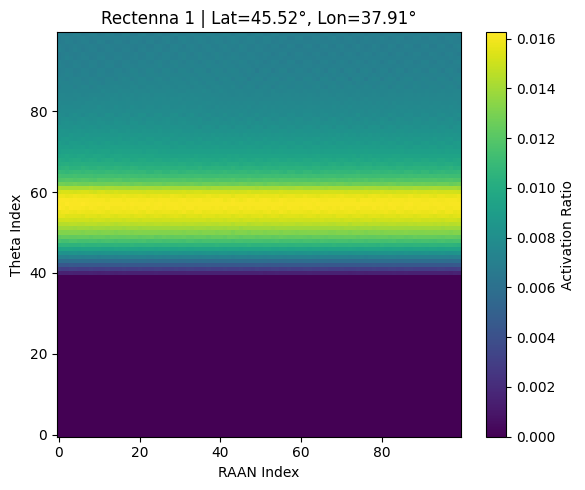

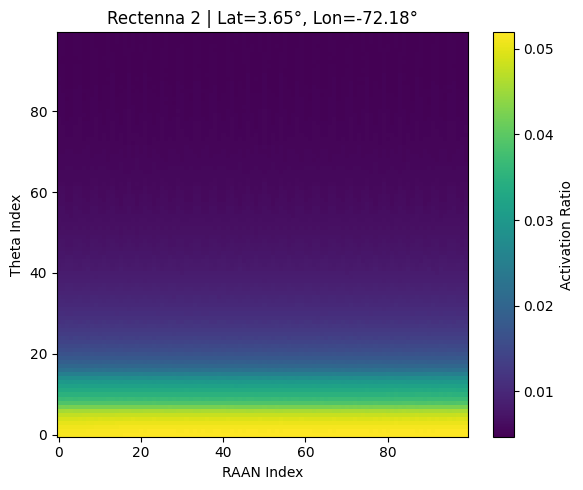

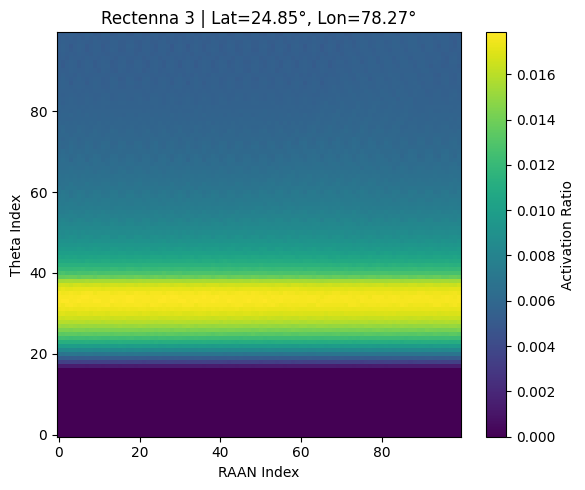

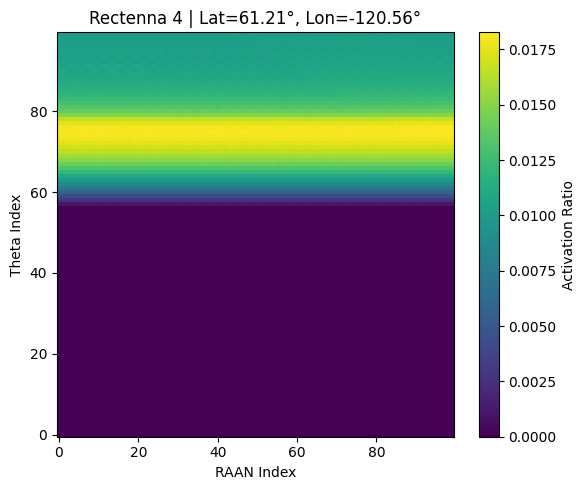

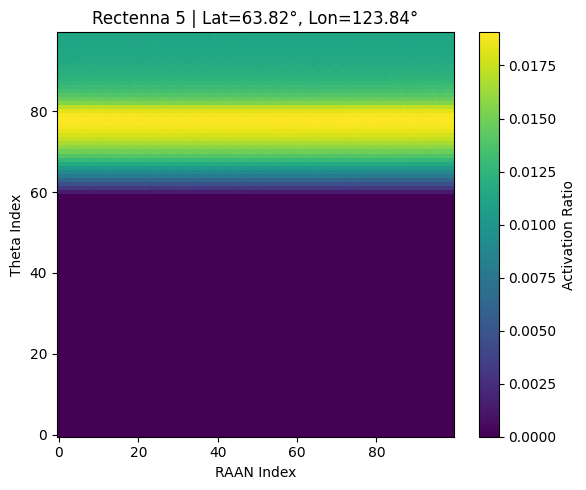

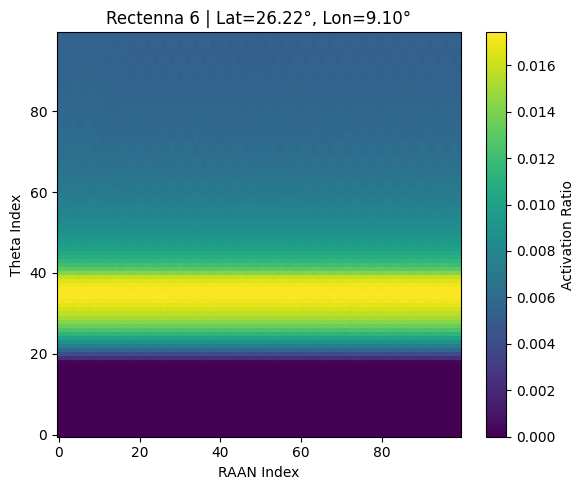

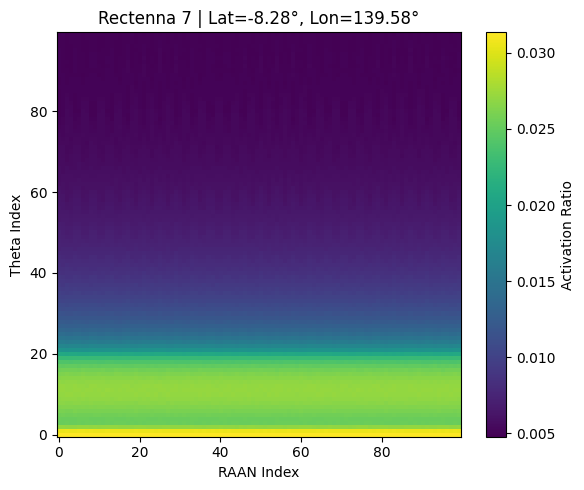

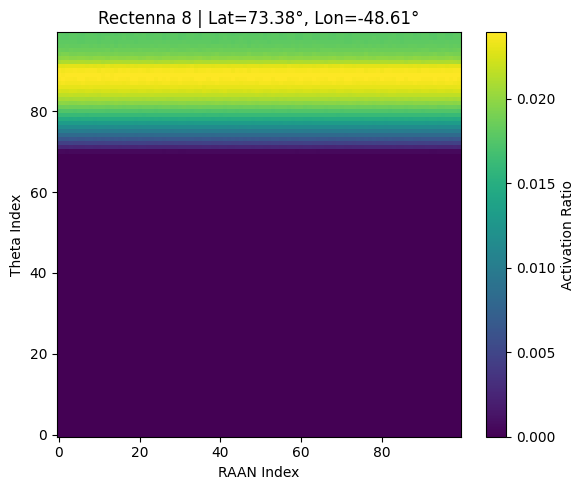

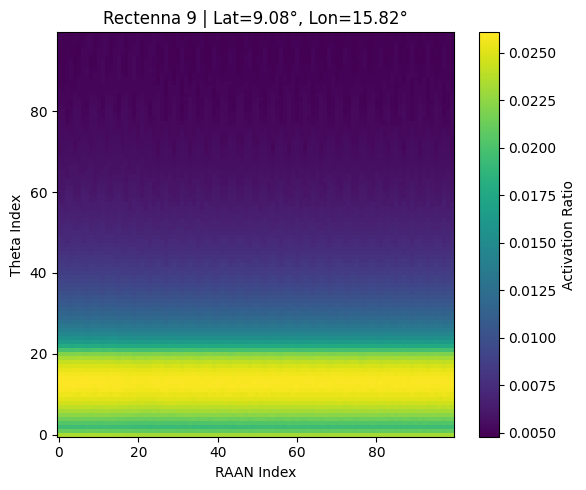

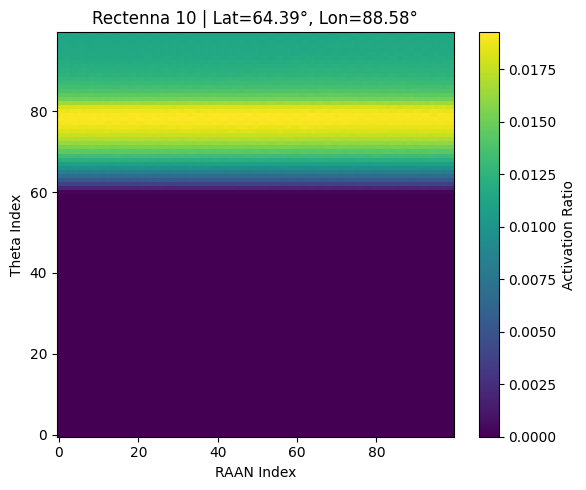

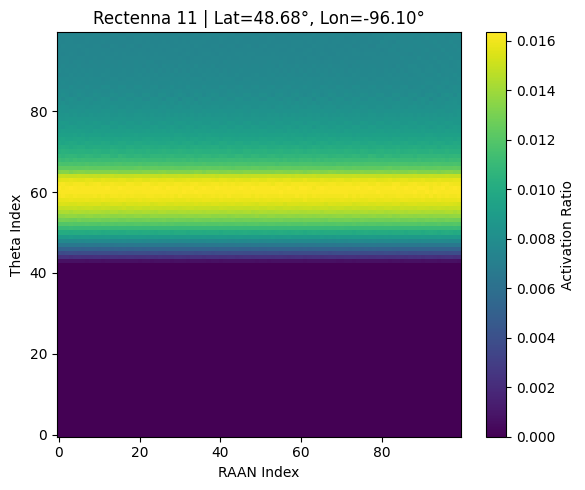

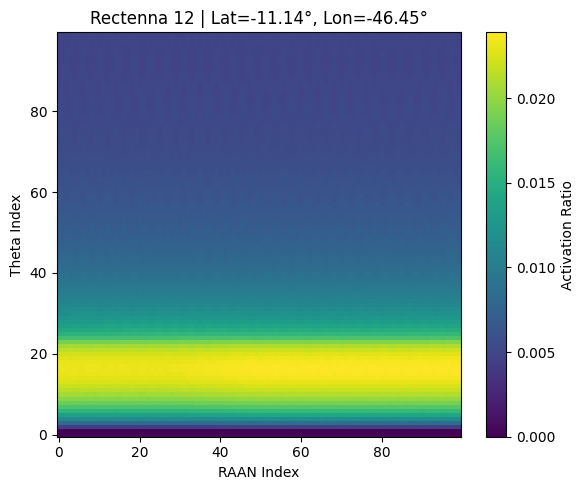

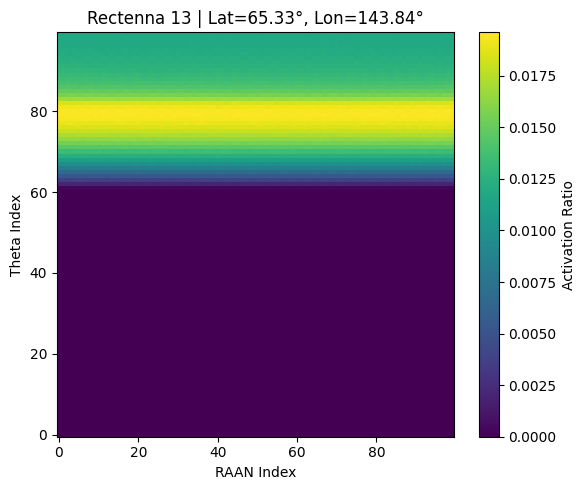

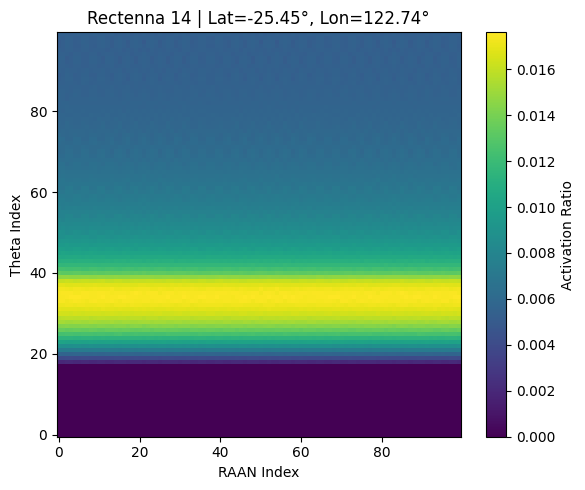

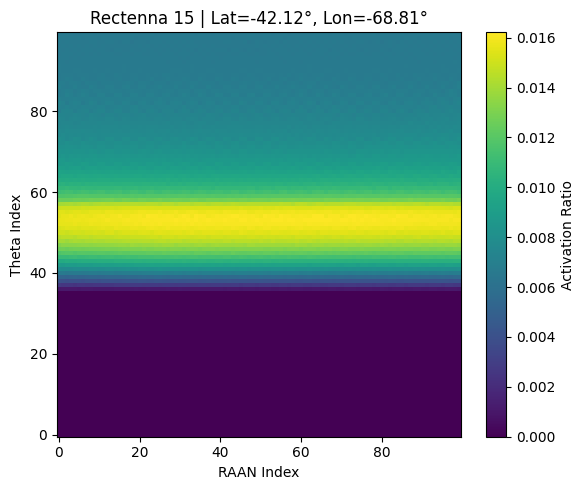

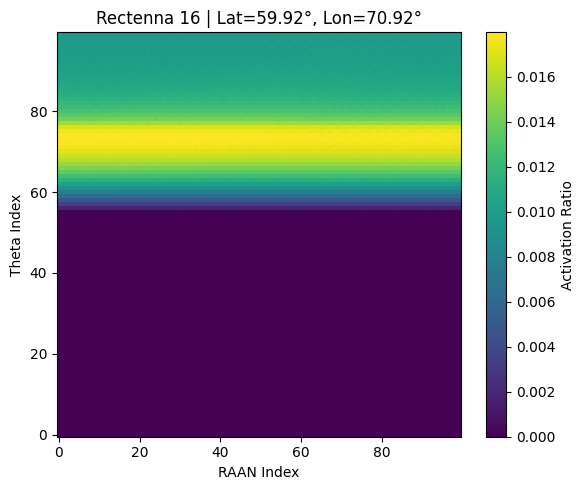

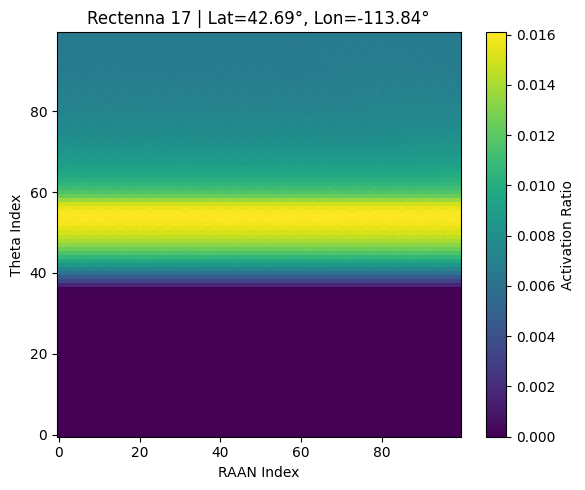

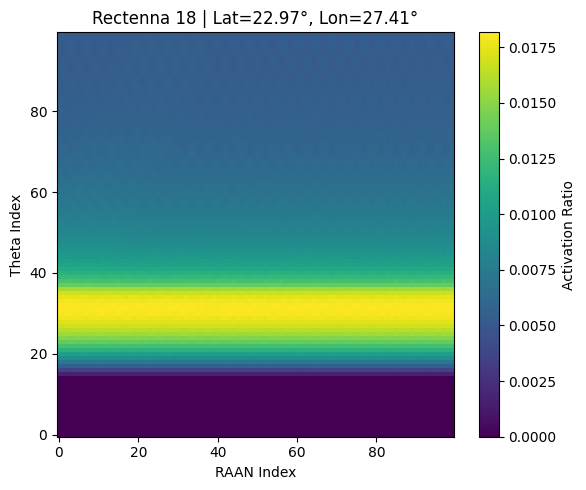

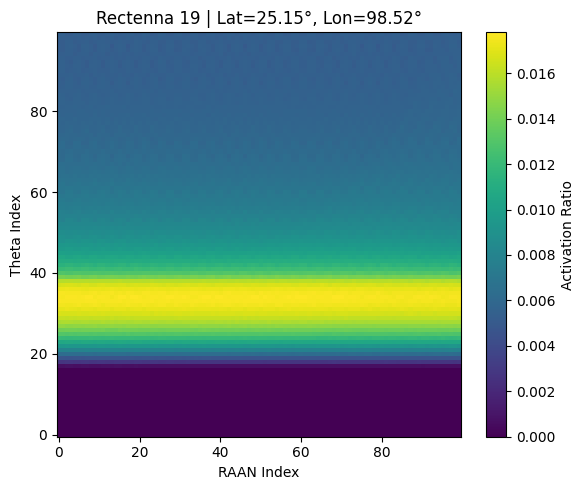

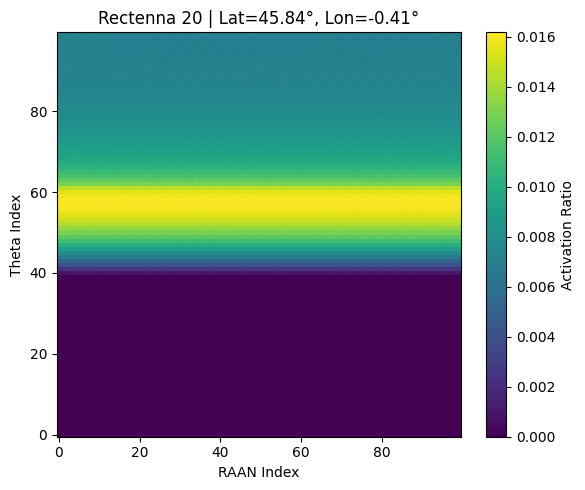

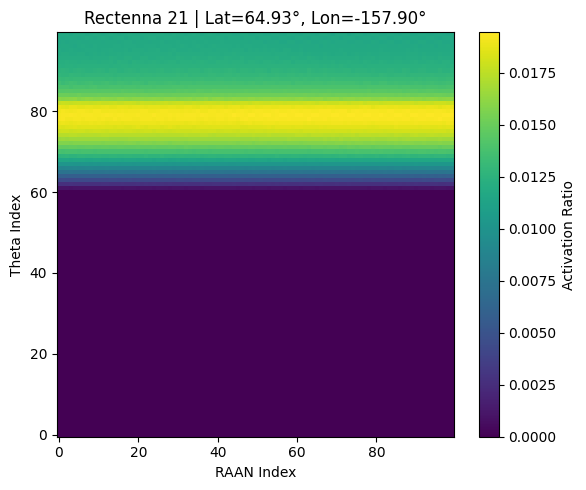

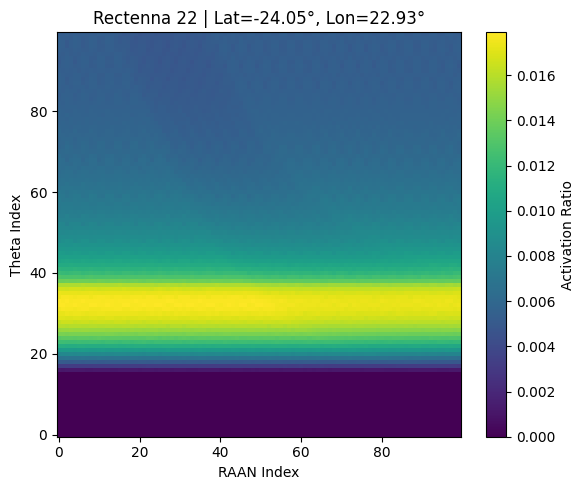

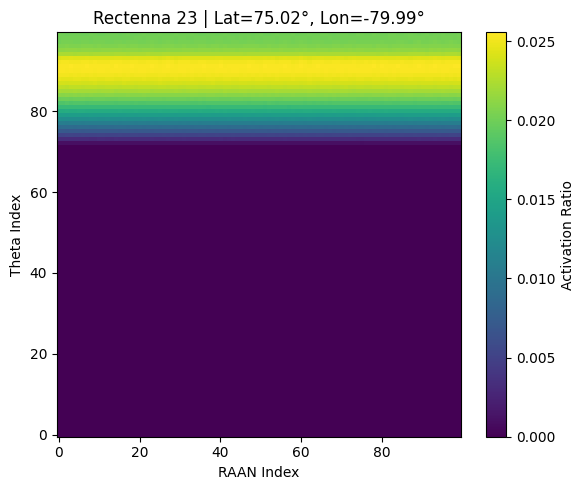

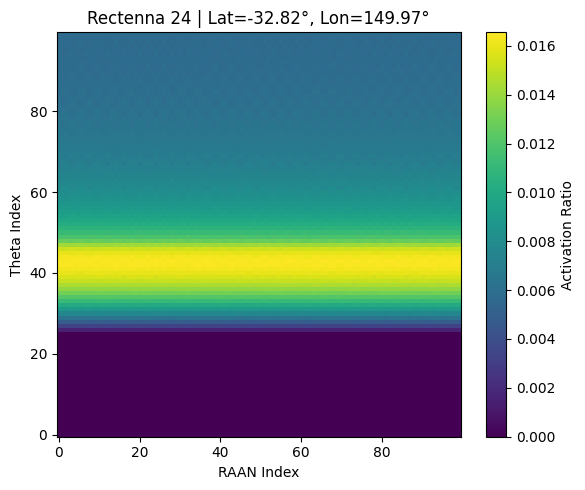

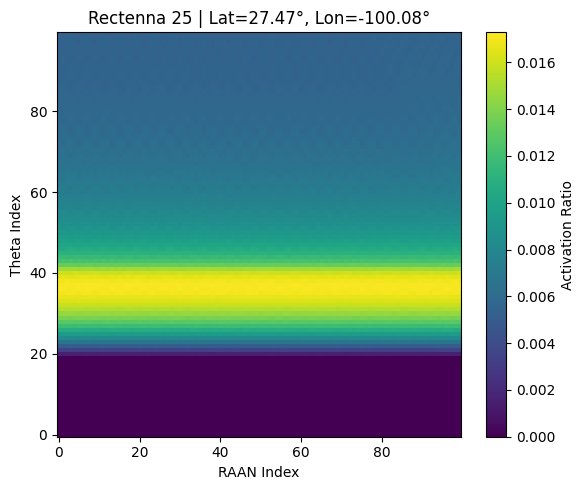

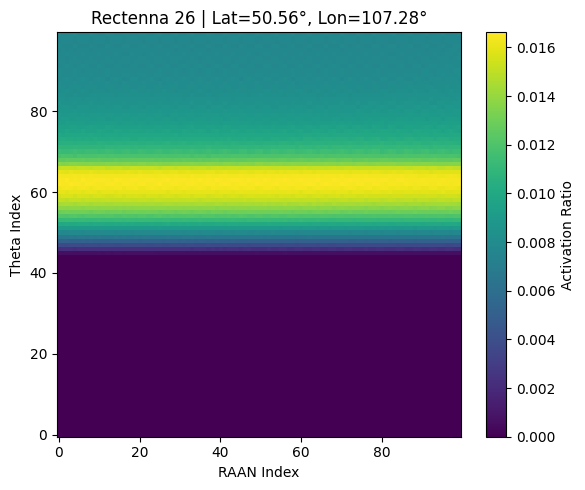

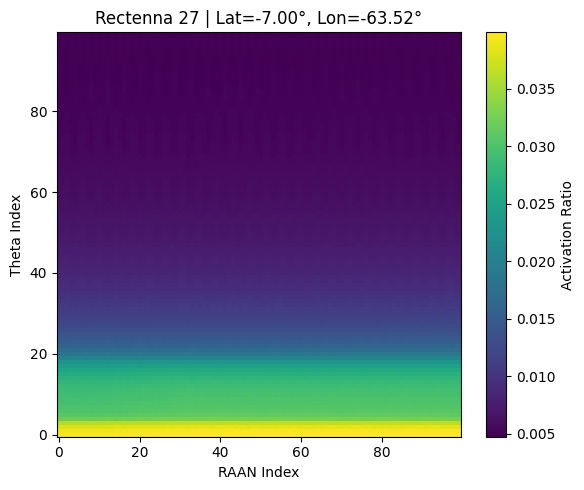

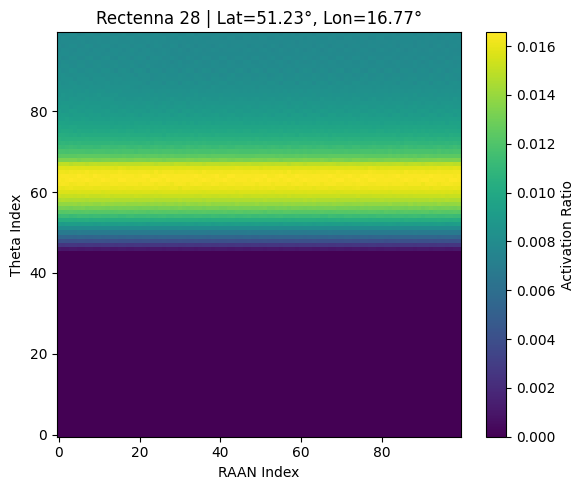

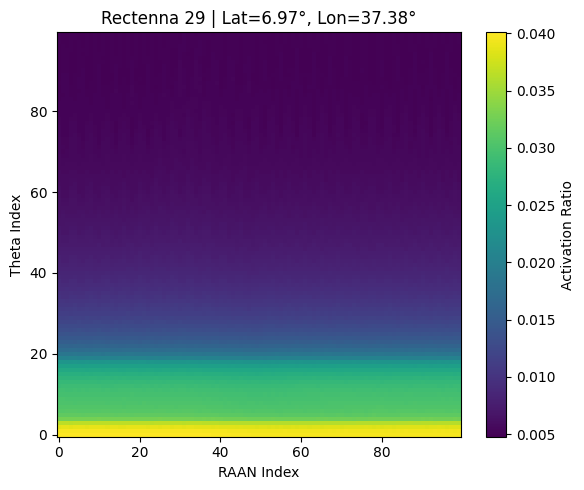

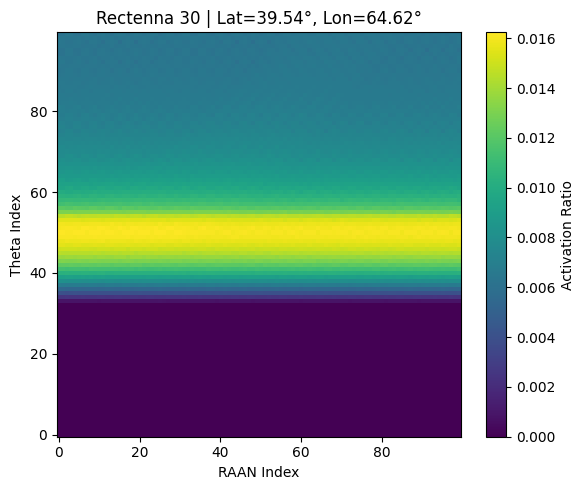

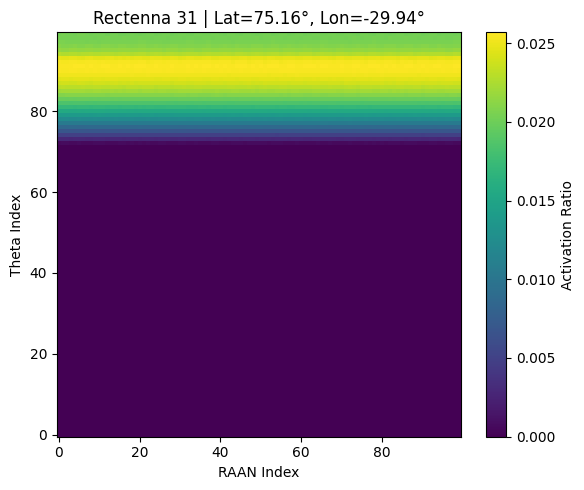

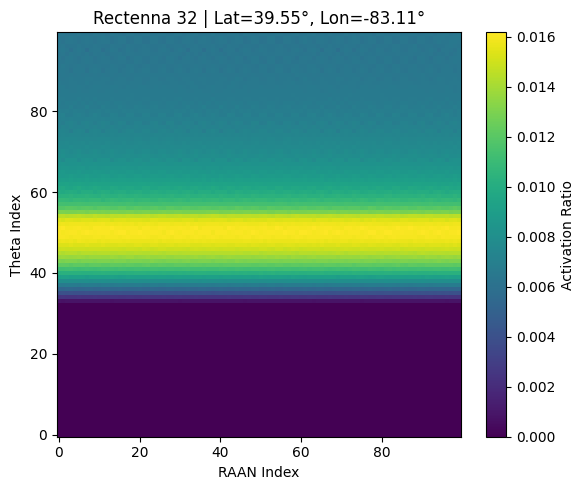

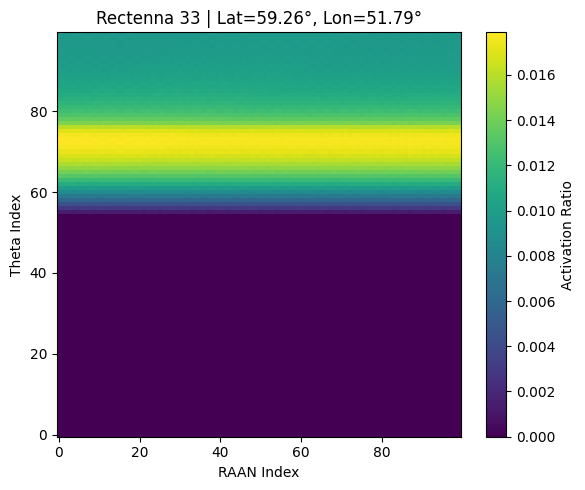

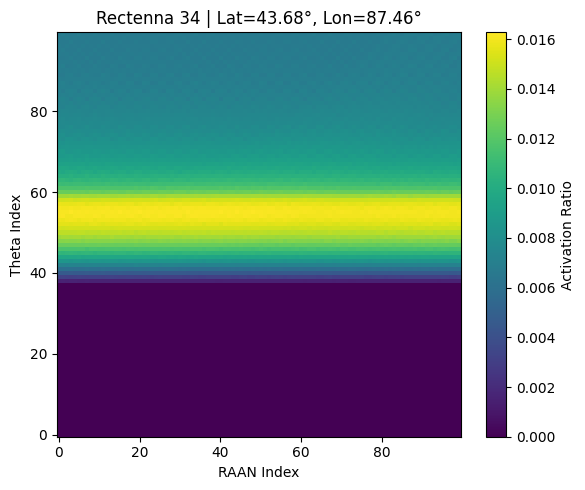

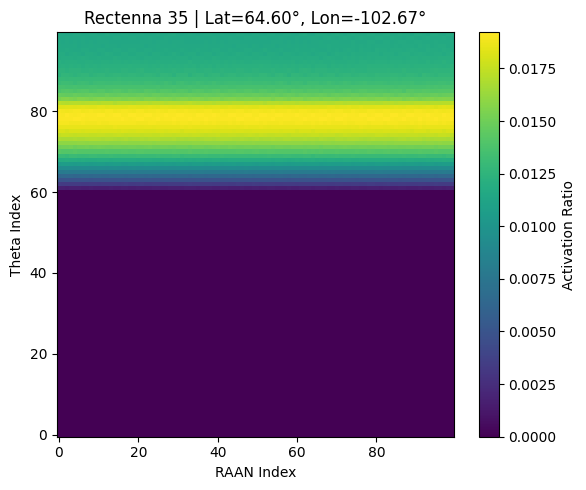

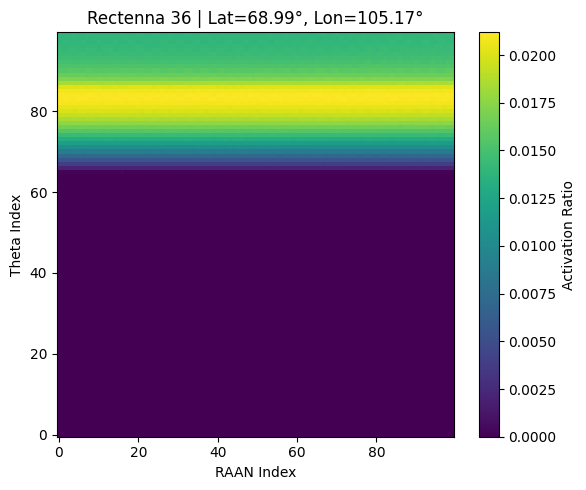

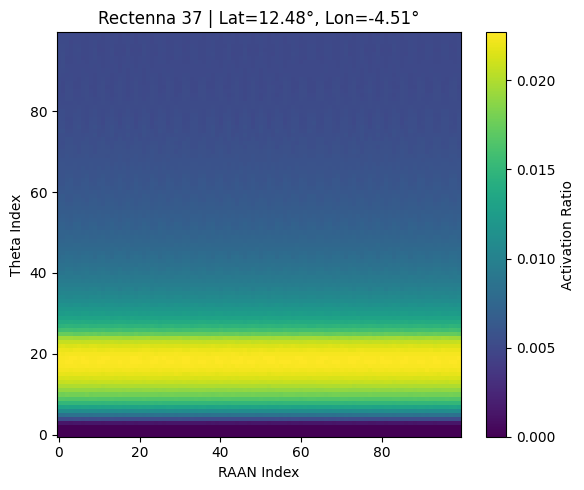

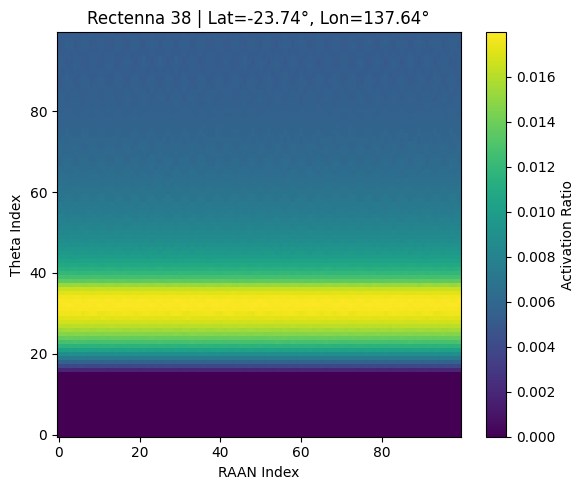

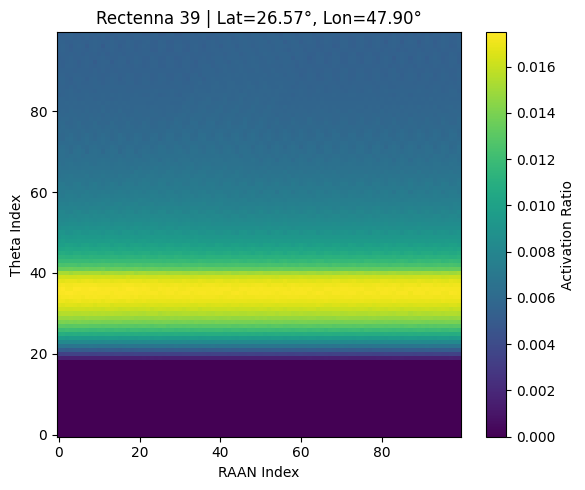

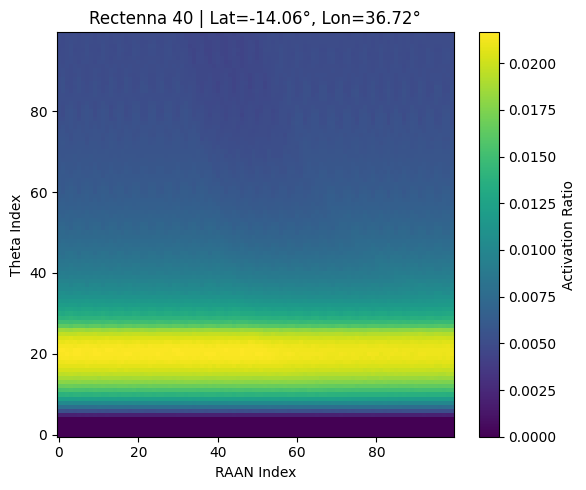

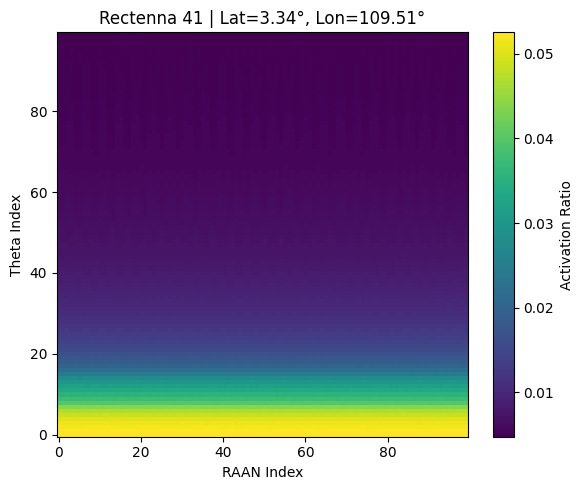

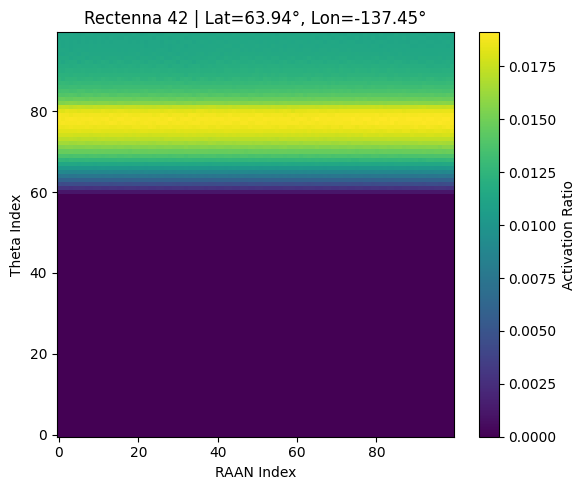

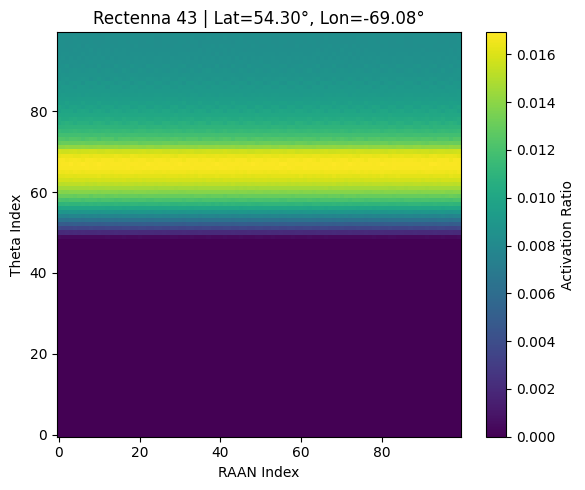

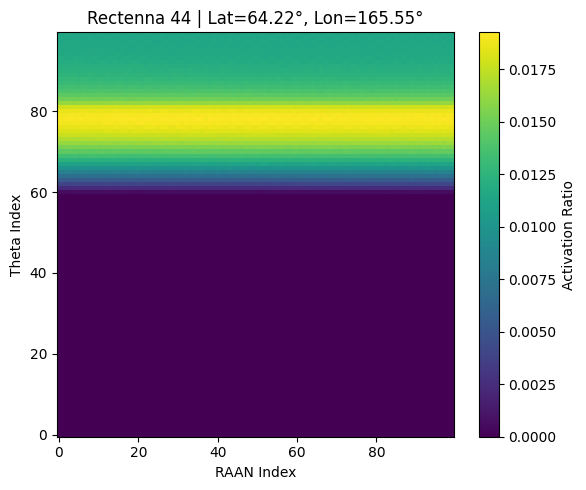

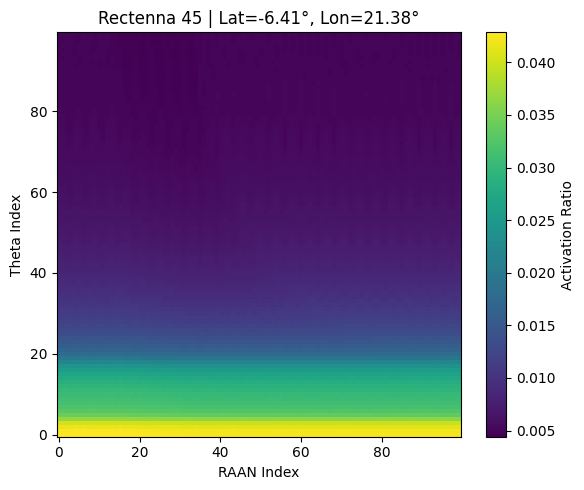

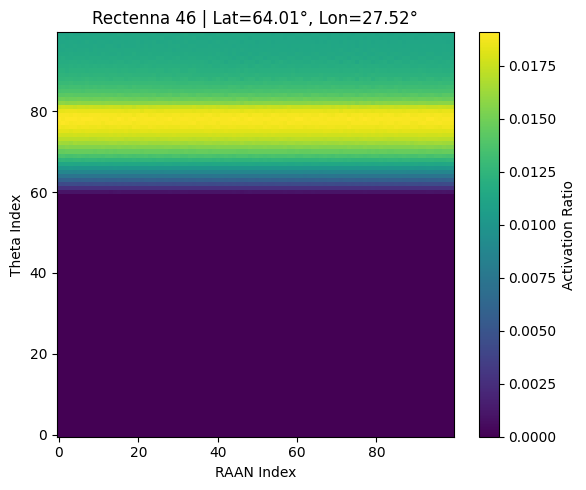

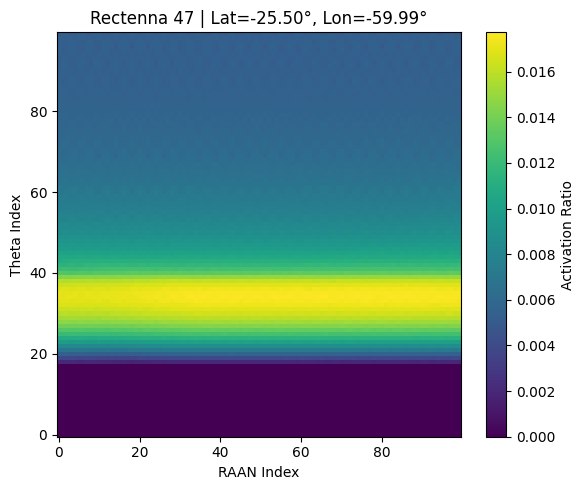

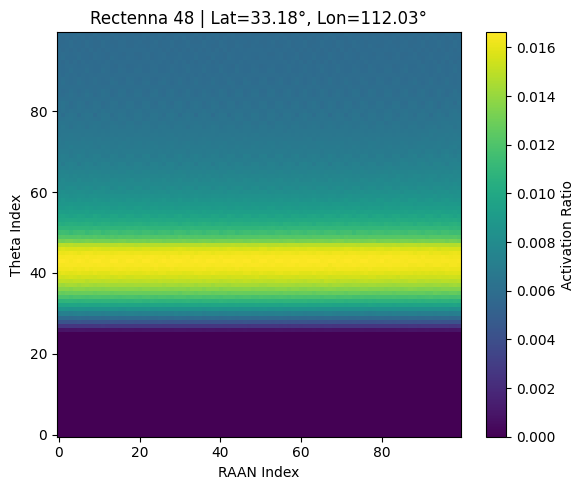

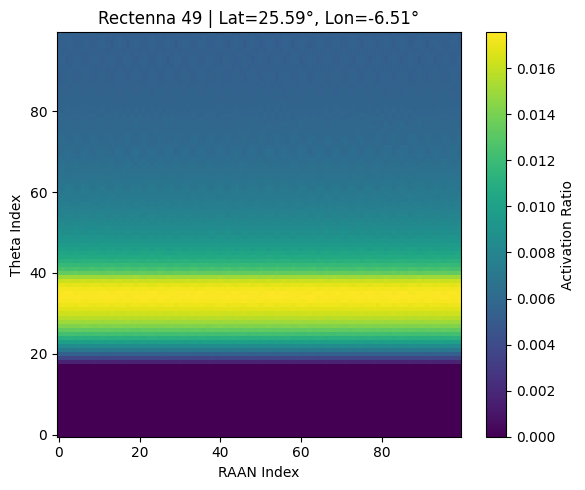

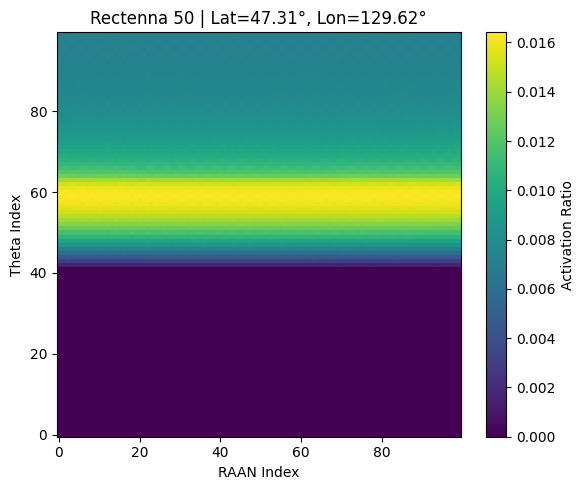


🔥 Generated 50 Heatmaps successfully!


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------------------
# Inputs expected:
#  result_tensor: shape (N_sat, N_sat, 50, 2)
#  data_rectanna_placement_radians: pandas DataFrame (50,2) containing [lat,lon]
#  theta_list_deg & raan_list_deg: used for labeling axes
# -------------------------------------------------------------

# 1) Extract ratio column -> (N_sat,N_sat,50)
ratio_tensor = result_tensor[...,1]   # keeps only ratio

N_sat = ratio_tensor.shape[0]
N_rect = ratio_tensor.shape[2]        # should be 50

print("\nNew Tensor Shape (ratios only):", ratio_tensor.shape)

# ---------- Plot 50 heatmaps ----------
fig_count = 0
for r in range(N_rect):

    heatmap = ratio_tensor[:,:,r]   # (N_sat,N_sat)
    lat, lon = np.rad2deg(data_rectanna_placement_radians.iloc[r])

    plt.figure(figsize=(6,5))
    plt.imshow(heatmap, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar(label="Activation Ratio")

    plt.title(f"Rectenna {r+1} | Lat={lat:.2f}°, Lon={lon:.2f}°")
    plt.xlabel("RAAN Index")
    plt.ylabel("Theta Index")

    plt.tight_layout()
    plt.show()

    fig_count += 1

print(f"\n🔥 Generated {fig_count} Heatmaps successfully!")


In [77]:
import numpy as np
import pulp


def solve_minimum_selection(
    data,
    val_threshold,
    verbose=False,
    gap_rel=0.001,
    time_limit=None,
):
    """
    Solve the minimal selection problem.

    Parameters
    ----------
    data : np.ndarray
        Tensor of shape (N_theta, N_raan, N_rect, 2).
        The last dimension has 2 "columns"; we ignore column 0 and use column 1.
        After ignoring we conceptually have (N_theta, N_raan, N_rect, 1),
        i.e. for each (theta_idx, raan_idx, rect_idx) we have a scalar in [0,1].
    val_threshold : float or np.ndarray
        Either a scalar threshold or an array of shape (N_rect,)
        specifying the minimum required sum for each rectenna.
    verbose : bool
        If True, prints MILP solver log.
    gap_rel : float
        Relative MIP gap at which CBC is allowed to stop, e.g. 0.001 = 0.1%.
    time_limit : float or None
        Optional time limit in seconds for CBC.

    Returns
    -------
    selected_indices : list of (theta_idx, raan_idx)
        List of grid points (theta, raan) that are selected in the (near-)optimal solution.
    status : str
        Solver status string from pulp.
    """

    # 1. Extract 2nd column → shape (N_theta, N_raan, N_rect, 1)
    vals = data[..., 1:2]  # keep as last-dim=1 for clarity

    N_theta, N_raan, N_rect, _ = vals.shape
    N_samples = N_theta * N_raan

    # 2. Flatten over (theta, raan) → shape (N_samples, N_rect)
    vals_flat = vals.reshape(N_samples, N_rect)

    # 3. Handle threshold
    if np.isscalar(val_threshold):
        threshold = np.full(N_rect, float(val_threshold))
    else:
        threshold = np.asarray(val_threshold, dtype=float)
        if threshold.shape != (N_rect,):
            raise ValueError(
                f"val_threshold must be scalar or shape (N_rect,), got {threshold.shape}"
            )

    # 4. Define ILP: minimize sum x_s, subject to:
    #    sum_s x_s * vals_flat[s, r] >= threshold[r] for all rectenna r
    prob = pulp.LpProblem("MinimumSelection", pulp.LpMinimize)

    # Binary decision variables: x_s ∈ {0,1}
    x = pulp.LpVariable.dicts(
        "x", range(N_samples), lowBound=0, upBound=1, cat=pulp.LpBinary
    )

    # Objective: minimize total number of selected samples
    prob += pulp.lpSum(x[s] for s in range(N_samples)), "Minimize_number_of_samples"

    # Constraints: for each rectenna r, sum_s x_s * vals_flat[s,r] >= threshold[r]
    for r in range(N_rect):
        prob += (
            pulp.lpSum(vals_flat[s, r] * x[s] for s in range(N_samples))
            >= threshold[r],
            f"rectenna_{r}_coverage",
        )

    # 5. Solve with CBC, enforcing relative gap
    solver = pulp.PULP_CBC_CMD(
        msg=verbose,
        gapRel=gap_rel,          # <-- 0.001 = 0.1% relative MIP gap
        timeLimit=time_limit,    # optional, can be None
    )
    prob.solve(solver)

    status = pulp.LpStatus[prob.status]
    print("MILP status:", status)

    # 6. Extract chosen samples (best incumbent, even if not proven optimal)
    chosen_samples = [s for s in range(N_samples) if pulp.value(x[s]) > 0.5]

    selected_indices = []
    for s in chosen_samples:
        theta_idx = s // N_raan
        raan_idx = s % N_raan
        selected_indices.append((theta_idx, raan_idx))

    return selected_indices, status


# --------------------------------------------------------------------
# Example usage (dummy data):
# --------------------------------------------------------------------
if __name__ == "__main__":
    N_theta = 100
    N_raan = 100
    N_rect = 50

    rng = np.random.default_rng(0)
    data = rng.random((N_theta, N_raan, N_rect, 2))

    val_threshold = 0.85

    selected, status = solve_minimum_selection(
        result_matrix,
        val_threshold,
        verbose=True,
        gap_rel=0.01,    # 0.1% gap
        time_limit=1000,  # or e.g. 300.0
    )
    print("Solver status:", status)
    print("Number of selected points:", len(selected))
    print("First few selected indices:", selected[:10])


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/raj/.local/lib/python3.10/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/fa287421067f407682dde1b5f8dc399b-pulp.mps -sec 1000 -ratio 0.01 -timeMode elapsed -branch -printingOptions all -solution /tmp/fa287421067f407682dde1b5f8dc399b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 55 COLUMNS
At line 327856 RHS
At line 327907 BOUNDS
At line 337908 ENDATA
Problem MODEL has 50 rows, 10000 columns and 297800 elements
Coin0008I MODEL read with 0 errors
seconds was changed from 1e+100 to 1000
ratioGap was changed from 0 to 0.01
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1180.3 - 1.10 seconds
Cgl0004I processed model has 50 rows, 9838 columns (9838 integer (9786 of which binary)) and 297675 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0038I Initial state - 25 integers unsatisfied sum - 6.78459
Cbc0038I P

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_selected_points(selected_indices, theta_list_deg, raan_list_deg, show_plots=True):
    """
    Convert selected (theta_idx, raan_idx) pairs into actual angles,
    compute 1D histograms in theta and RAAN, and generate + save plots.

    SAVES:
      select_angle_plots/
        ├─ theta_histogram.png
        ├─ raan_histogram.png
        └─ heatmap_selected_points.png
    """

    # Ensure directory exists
    save_dir = "select_angle_plots"
    os.makedirs(save_dir, exist_ok=True)

    selected_indices = list(selected_indices)
    N_theta = len(theta_list_deg)
    N_raan = len(raan_list_deg)

    # 1) Convert index → degree values
    selected_angles = [(theta_list_deg[ti], raan_list_deg[ri]) for ti, ri in selected_indices]

    # 2) Build 2D mask
    selection_mask = np.zeros((N_theta, N_raan), dtype=int)
    for ti, ri in selected_indices:
        selection_mask[ti, ri] = 1

    # 3) 1D histograms
    theta_counts = selection_mask.sum(axis=1)
    raan_counts  = selection_mask.sum(axis=0)

    # ---------- PLOTS ----------
    # ---- Theta Histogram ----
    plt.figure(figsize=(8,3))
    plt.bar(theta_list_deg, theta_counts, width=(theta_list_deg[1]-theta_list_deg[0]))
    plt.xlabel("Theta (deg)")
    plt.ylabel("Count")
    plt.title("Histogram of Selected Theta Values")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/theta_histogram.png", dpi=300)
    if show_plots: plt.show()
    plt.close()

    # ---- RAAN Histogram ----
    plt.figure(figsize=(8,3))
    plt.bar(raan_list_deg, raan_counts, width=(raan_list_deg[1]-raan_list_deg[0]))
    plt.xlabel("RAAN (deg)")
    plt.ylabel("Count")
    plt.title("Histogram of Selected RAAN Values")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/raan_histogram.png", dpi=300)
    if show_plots: plt.show()
    plt.close()

    # ---- Heatmap ----
    plt.figure(figsize=(6,5))
    plt.imshow(
        selection_mask,
        origin='lower',
        aspect='auto',
        extent=(raan_list_deg[0], raan_list_deg[-1], theta_list_deg[0], theta_list_deg[-1])
    )
    plt.colorbar(label="Selected (1=chosen)")
    plt.xlabel("RAAN (deg)")
    plt.ylabel("Theta (deg)")
    plt.title("Heatmap of Selected Points")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/heatmap_selected_points.png", dpi=300)
    if show_plots: plt.show()
    plt.close()

    print(f"\n📁 Plots saved in folder: {save_dir}/\n")

    return selected_angles, theta_counts, raan_counts, selection_mask


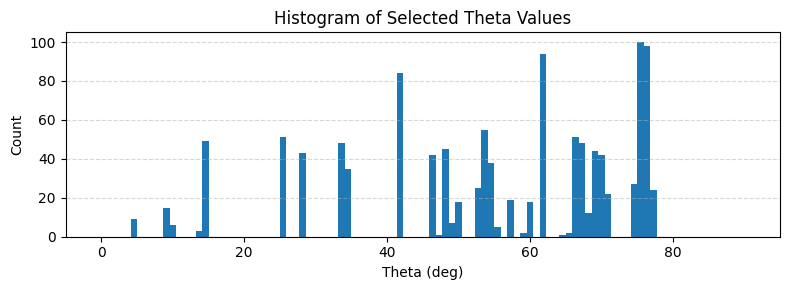

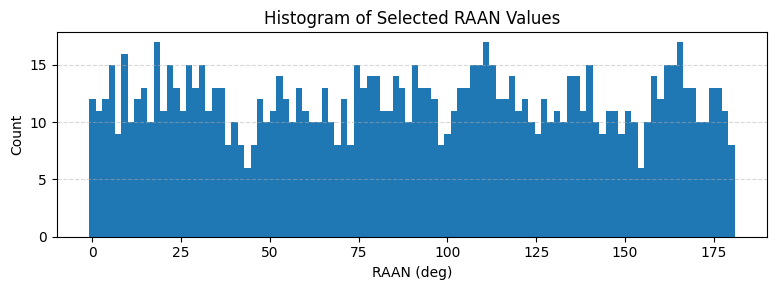

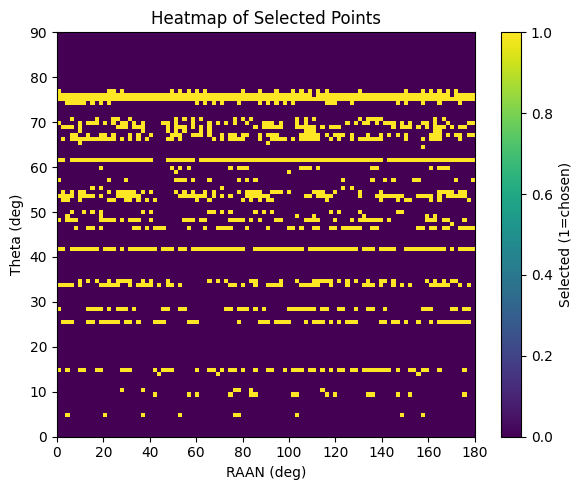


📁 Plots saved in folder: select_angle_plots/



In [90]:
selected_angles, theta_counts, raan_counts, mask = analyze_selected_points(
    selected,
    theta_list_deg,
    raan_list_deg,
    show_plots=True,
)

In [85]:
arr= np.array(selected_angles)
arr


array([[  4.54545455,   3.63636364],
       [  4.54545455,  20.        ],
       [  4.54545455,  36.36363636],
       ...,
       [ 77.27272727, 165.45454545],
       [ 77.27272727, 169.09090909],
       [ 77.27272727, 172.72727273]], shape=(1183, 2))

In [86]:
np.save("selected_angles.npy", arr)
print("Saved as selected_angles.npy")


Saved as selected_angles.npy


In [87]:
np.savetxt("selected_angles.csv", arr, delimiter=",", fmt="%.5f",
           header="theta_deg,raan_deg", comments="")
print("Saved as selected_angles.csv")


Saved as selected_angles.csv


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# -------------------------------------------------------------
# Inputs expected:
#  result_tensor: shape (N_sat, N_sat, 50, 2)
#  data_rectanna_placement_radians: pandas DataFrame (50,2) containing [lat,lon]
#  theta_list_deg & raan_list_deg: used for labeling axes
# -------------------------------------------------------------

# 1) Extract ratio column -> (N_sat,N_sat,50)
ratio_tensor = result_tensor[...,1]   # keeps only ratio

N_sat = ratio_tensor.shape[0]
N_rect = ratio_tensor.shape[2]        # should be 50

print("\nNew Tensor Shape (ratios only):", ratio_tensor.shape)

# -------------------------------------------------------------
#  Create output directory
# -------------------------------------------------------------
save_dir = "rectenna_heatmaps"
os.makedirs(save_dir, exist_ok=True)

# ---------- Plot + SAVE 50 heatmaps ----------
fig_count = 0
for r in range(N_rect):

    heatmap = ratio_tensor[:,:,r]   # (N_sat,N_sat)
    lat, lon = np.rad2deg(data_rectanna_placement_radians.iloc[r])

    plt.figure(figsize=(6,5))
    plt.imshow(heatmap, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar(label="Activation Ratio")

    plt.title(f"Rectenna {r+1} | Lat={lat:.2f}°, Lon={lon:.2f}°")
    plt.xlabel("RAAN Index")
    plt.ylabel("Theta Index")
    plt.tight_layout()

    # ----------- SAVE with unique name -----------
    fname = f"rectenna_{r+1}_lat{lat:.2f}_lon{lon:.2f}.png"
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.close()  # <-- prevents figure memory buildup

    fig_count += 1

print(f"\n🔥 Saved {fig_count} Heatmaps in folder: '{save_dir}'")



New Tensor Shape (ratios only): torch.Size([100, 100, 50])

🔥 Saved 50 Heatmaps in folder: 'rectenna_heatmaps'


In [ ]:
theta_sat_values = np.linspace(0, np.pi, 100)

# Divide -pi/2 to pi/2 into 100 parts
raan_sat_values = np.linspace(-np.pi/2, np.pi/2, 100)

# Nested loop
for theta in theta1_values:
    for raan in theta2_values:

